In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_filtered_rows_90per_coverage.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_filtered_rows_90per_coverage.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

In [4]:
#checking max visibility of file
max_visibility = CV_rows["HourlyVisibility"].max()
print("Maximum HourlyVisibility:", max_visibility)

Maximum HourlyVisibility: 16.0


In [5]:
# List all station names in CV_rows
CV_stations = CV_rows["STATION"].unique()
print("Stations in CV_rows:", CV_stations)

Stations in CV_rows: <StringArray>
[      'FRESNO YOSEMITE INTL',     'LIVERMORE MUNICIPAL AP',
                 'CASTLE AFB',           'TRAVIS FIELD AFB',
                'STOCKTON AP',             'BAKERSFIELD AP',
         'LEMOORE REEVES NAS',      'SACRAMENTO MATHER AFB',
   'SACRAMENTO MCCLELLAN AFB',          'RED BLUFF MUNI AP',
         'SACRAMENTO AP ASOS', 'SACRAMENTO METROPOLITAN AP',
                  'BEALE AFB',                 'REDDING AP']
Length: 14, dtype: str


In [6]:
print(CV_rows.shape)

(8221094, 18)


In [7]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
# the ~ operator is used to negate the condition, so we keep only the rows where the month is not in the specified list
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3634348, 18)


In [8]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold in case the csv was cleaned with a different threshold

CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17.000]

CV_filtered_rows1 = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

# Filter based on precipitation to see how many rows are removed by the visibility threshold
CV_filtered_rows2 = CV_rows[CV_rows["HourlyPrecipitation"] < 0.03]

print("CV_filtered_rows:", CV_filtered_rows.shape)
print("CV_filtered_rows1:", CV_filtered_rows1.shape)
print("CV_filtered_rows2:", CV_filtered_rows2.shape)
print("CV_rows:", CV_rows.shape)

CV_filtered_rows: (3634348, 18)
CV_filtered_rows1: (3505371, 18)
CV_filtered_rows2: (3505371, 18)
CV_rows: (3634348, 18)


In [9]:
#counting days measured per year per station
filtered_days_year = (
    # From CV_filtered_rows
    CV_filtered_rows
    # Drop duplicates based on station, year, month, and day to ensure each day is only counted once
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # group by station and year
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique days
    .size()
    # rename the 'size' column to 'filtered_days'
    .rename(columns={'size': 'filtered_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [10]:
# Find stations with data back to at least 1975
stations_pre1975 = (
    # Group CV_rows by station
    CV_rows.groupby('STATION')['year']
    # find the minimum year 
    .min()
    # Use .loc to filter for stations with data back to at least 1975
    .loc[lambda s: s <= 1975]
    # Get the list of station IDs
    .index
    # Make it a list
    .tolist()
)

# Print list
print(len(stations_pre1975), "stations with data back to at least 1975")
print(stations_pre1975)

# make dateframe with station locations
station_locations = (
    # Filter CV_rows to include only stations with data back to at least 1975
    CV_rows[CV_rows['STATION'].isin(stations_pre1975)]
    # Drop duplicate rows based on the 'STATION' column to ensure each station is represented only once
    .drop_duplicates(subset=['STATION'])
    # Select only the 'STATION', 'LATITUDE', and 'LONGITUDE' columns
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    # Reset the index to ensure a clean DataFrame without the old index
    .reset_index(drop=True)
)

13 stations with data back to at least 1975
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB']


In [11]:
# display rows with missing HourlyVisibility
print(CV_rows[CV_rows['HourlyVisibility'].isna()])

Empty DataFrame
Columns: [STATION_ID, LATITUDE, LONGITUDE, DATE, REPORT_TYPE, HourlyDewPointTemperature, HourlyDryBulbTemperature, HourlyPrecipitation, HourlyVisibility, HourlyWindDirection, HourlyWindSpeed, MonthlyNumberDaysWithHeavyFog, year, month, day, hour, minute, STATION]
Index: []


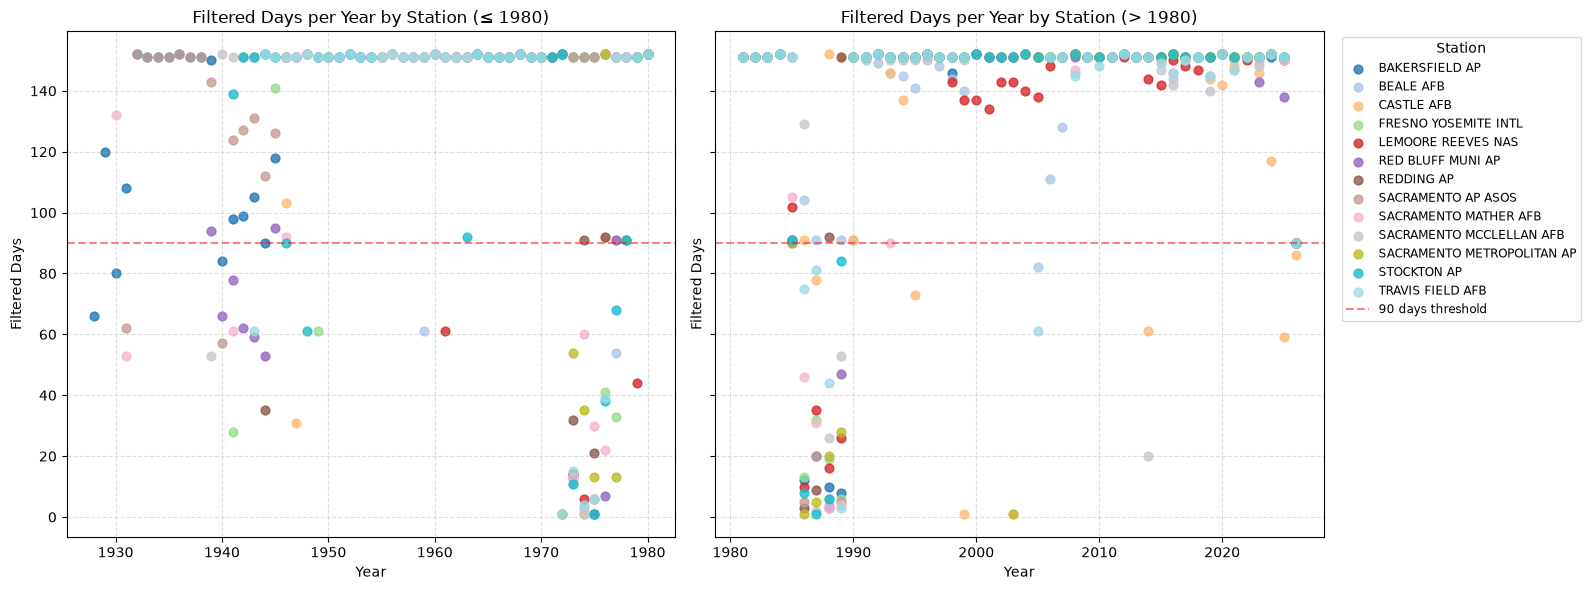

In [12]:
# plot the filtered days per year for the outliers for each station
# doing this in order to see where outlier years are
# use stations with data back to at least 1975
plot_stations = [st for st in stations_pre1975 if st in filtered_days_year['STATION'].unique()]
# define colors for each station using a colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
# create a dictionary mapping each station to its corresponding color
color_map = dict(zip(plot_stations, colors))

# filtered_pre1975 is needed to be distinct from plot_stations
# plot_stations is a list of station names filtered_days_year contains actual numerical data
# including the count of filtered days.
# By filtering filtered_days_year to include only the stations in plot_stations
# we ensure that we are working with the correct subset of data for plotting.
filtered_pre1975 = filtered_days_year[filtered_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Loop through each station and plot the filtered days per year for the two time periods
for station in plot_stations:
    # station_df is defined to hold the filtered data for the current station, sorted by year
    station_df = filtered_pre1975[filtered_pre1975['STATION'] == station].sort_values('year')
    # pre_df is the filtered data for years <= 1980
    pre_df = station_df[station_df['year'] <= 1980]
    # post_df is the filtered data for years > 1980
    post_df = station_df[station_df['year'] > 1980]

# if pre_df is not empty, plot the data for years ≤ 1980 on the first subplot
    if not pre_df.empty:
        # axes[0] = first subplot
        axes[0].scatter(
            # use the 'year' column for the x-axis and 'filtered_days' for the y-axis
            pre_df['year'],
            pre_df['filtered_days'],
            # set s=40 to set size of points
            s=40,
            # set the color of the points based on the station's assigned color
            color=color_map[station],
            # set the transparency of the points to 0.8
            alpha=0.8,
            # label the points with the station name in the legend
            label=station
        )

# if post_df is not empty, plot the data for years > 1980 on the second subplot
    if not post_df.empty:
        # axes[1] = second subplot
        axes[1].scatter(
            # use the 'year' column for the x-axis and 'filtered_days' for the y-axis
            post_df['year'],
            post_df['filtered_days'],
            # set s=40 to set size of points
            s=40,
            # set the color of the points based on the station's assigned color
            color=color_map[station],
            # set the transparency of the points to 0.8
            alpha=0.8,
            # label the points with the station name in the legend
            label=station
        )

# Set titles for plots
axes[0].set_title('Filtered Days per Year by Station (≤ 1980)')
axes[1].set_title('Filtered Days per Year by Station (> 1980)')

# for each subplot
for ax in axes:
    # set x and y labels
    ax.set_xlabel('Year')
    ax.set_ylabel('Filtered Days')
    # enable grid with dashed lines and set transparency
    ax.grid(True, linestyle='--', alpha=0.4)
    # add a horizontal line at y=90 to indicate the cutoff
    ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90 days threshold')

# Add legends to both subplots, placing them outside the plot area
axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# use tight_layout to fit subplots to figure area.
plt.tight_layout()
# display the plots
plt.show()

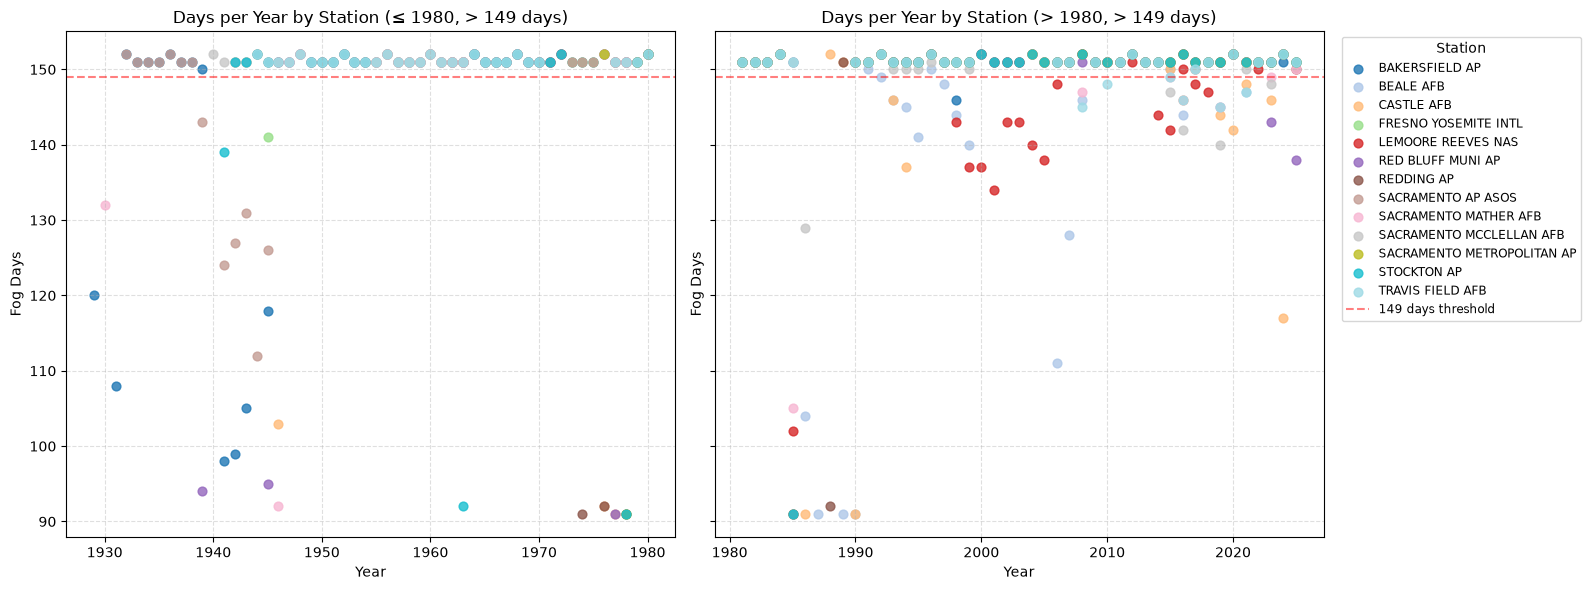

Stations with > 149 days: 13
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB']


In [13]:
# Remove stations with less than or only 149 days counted
filtered_days_year_filtered = filtered_days_year[filtered_days_year['filtered_days'] > 90]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in filtered_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1975 stations with > 149 fog days
filtered_pre1975_filtered = filtered_days_year_filtered[filtered_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = filtered_pre1975_filtered[filtered_pre1975_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 149 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 149 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 149 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [14]:
# Remove stations with 149 or fewer days counted
filtered_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 90].copy()

# Get the valid station-year combinations for merging
valid_station_years = filtered_days_year_no_outliers[["STATION", "year"]]
# Merge the filtered rows with the valid station-year combinations to remove outliers
CV_filtered_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", filtered_days_year_no_outliers.shape[0])
print("CV_filtered_rows_no_outliers:", CV_filtered_rows_no_outliers.shape)

Station-years kept: 864
CV_filtered_rows_no_outliers: (3509378, 18)


In [15]:
# Remove duplicate hours for each station-year-month-day-hour combination
CV_filtered_rows_no_outliers = CV_filtered_rows_no_outliers.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

print("CV_filtered_rows_no_outliers after removing duplicates:", CV_filtered_rows_no_outliers.shape)

CV_filtered_rows_no_outliers after removing duplicates: (2936739, 18)


In [16]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000 and < 0.403 km
low_vis_rows = CV_filtered_rows_no_outliers[
    (CV_filtered_rows_no_outliers["HourlyVisibility"] < 0.403)
    & (CV_filtered_rows_no_outliers["HourlyPrecipitation"] < 0.03)
]
low_vis_rows_1km = CV_filtered_rows_no_outliers[
    (CV_filtered_rows_no_outliers["HourlyVisibility"] < 1.000)
    & (CV_filtered_rows_no_outliers["HourlyPrecipitation"] < 0.03)
]

# Check the number of rows in each filtered dataframe
print("CV_filtered_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_filtered_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)

CV_filtered_rows_no_outliers with HourlyVisibility < 0.403: (101451, 18)
CV_filtered_rows_no_outliers with HourlyVisibility < 1.000: (130963, 18)


In [17]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    # Starting from low_vis_rows (HourlyVisibility < 0.403 km for valid years) 
    low_vis_rows
    # Drop duplicate station-year-month-day combinations
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # Group by station and year to count the number of unique fog days
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique fog days
    .size()
    # rename the 'size' column to 'fog_days'
    .rename(columns={'size': 'fog_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

low_vis_fog_days_year_1km = (
    # Starting from low_vis_rows_1km (HourlyVisibility < 1.000 km for valid years)
    low_vis_rows_1km
    # Drop duplicate station-year-month-day combinations
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # Group by station and year to count the number of unique fog days
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique fog days
    .size()
    # rename the 'size' column to 'fog_days'
    .rename(columns={'size': 'fog_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

In [18]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
# get the stations with at least 30 years of data
# stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(CV_filtered_rows_no_outliers["STATION"].unique())
].copy()

# print to check
print("Stations kept:", len(CV_filtered_rows_no_outliers["STATION"].unique()))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

# print the number of unique station-years for each station in low_vis_fog_days_year
station_year_counts_1km = low_vis_fog_days_year_1km.groupby("STATION")["year"].nunique()
# Determine the stations with at least 30 years of data for the 1km visibility threshold
# stations_with_30_years_1km = station_year_counts_1km[station_year_counts_1km >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered_1km = low_vis_fog_days_year_1km[
    low_vis_fog_days_year_1km["STATION"].isin(CV_filtered_rows_no_outliers["STATION"].unique())
].copy()

# print to check
print("Stations kept:", len(CV_filtered_rows_no_outliers["STATION"].unique()))
print("Filtered low_vis_fog_days_year_1km rows:", low_vis_fog_days_year_filtered_1km.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (863, 3)
Stations kept: 14
Filtered low_vis_fog_days_year_1km rows: (863, 3)


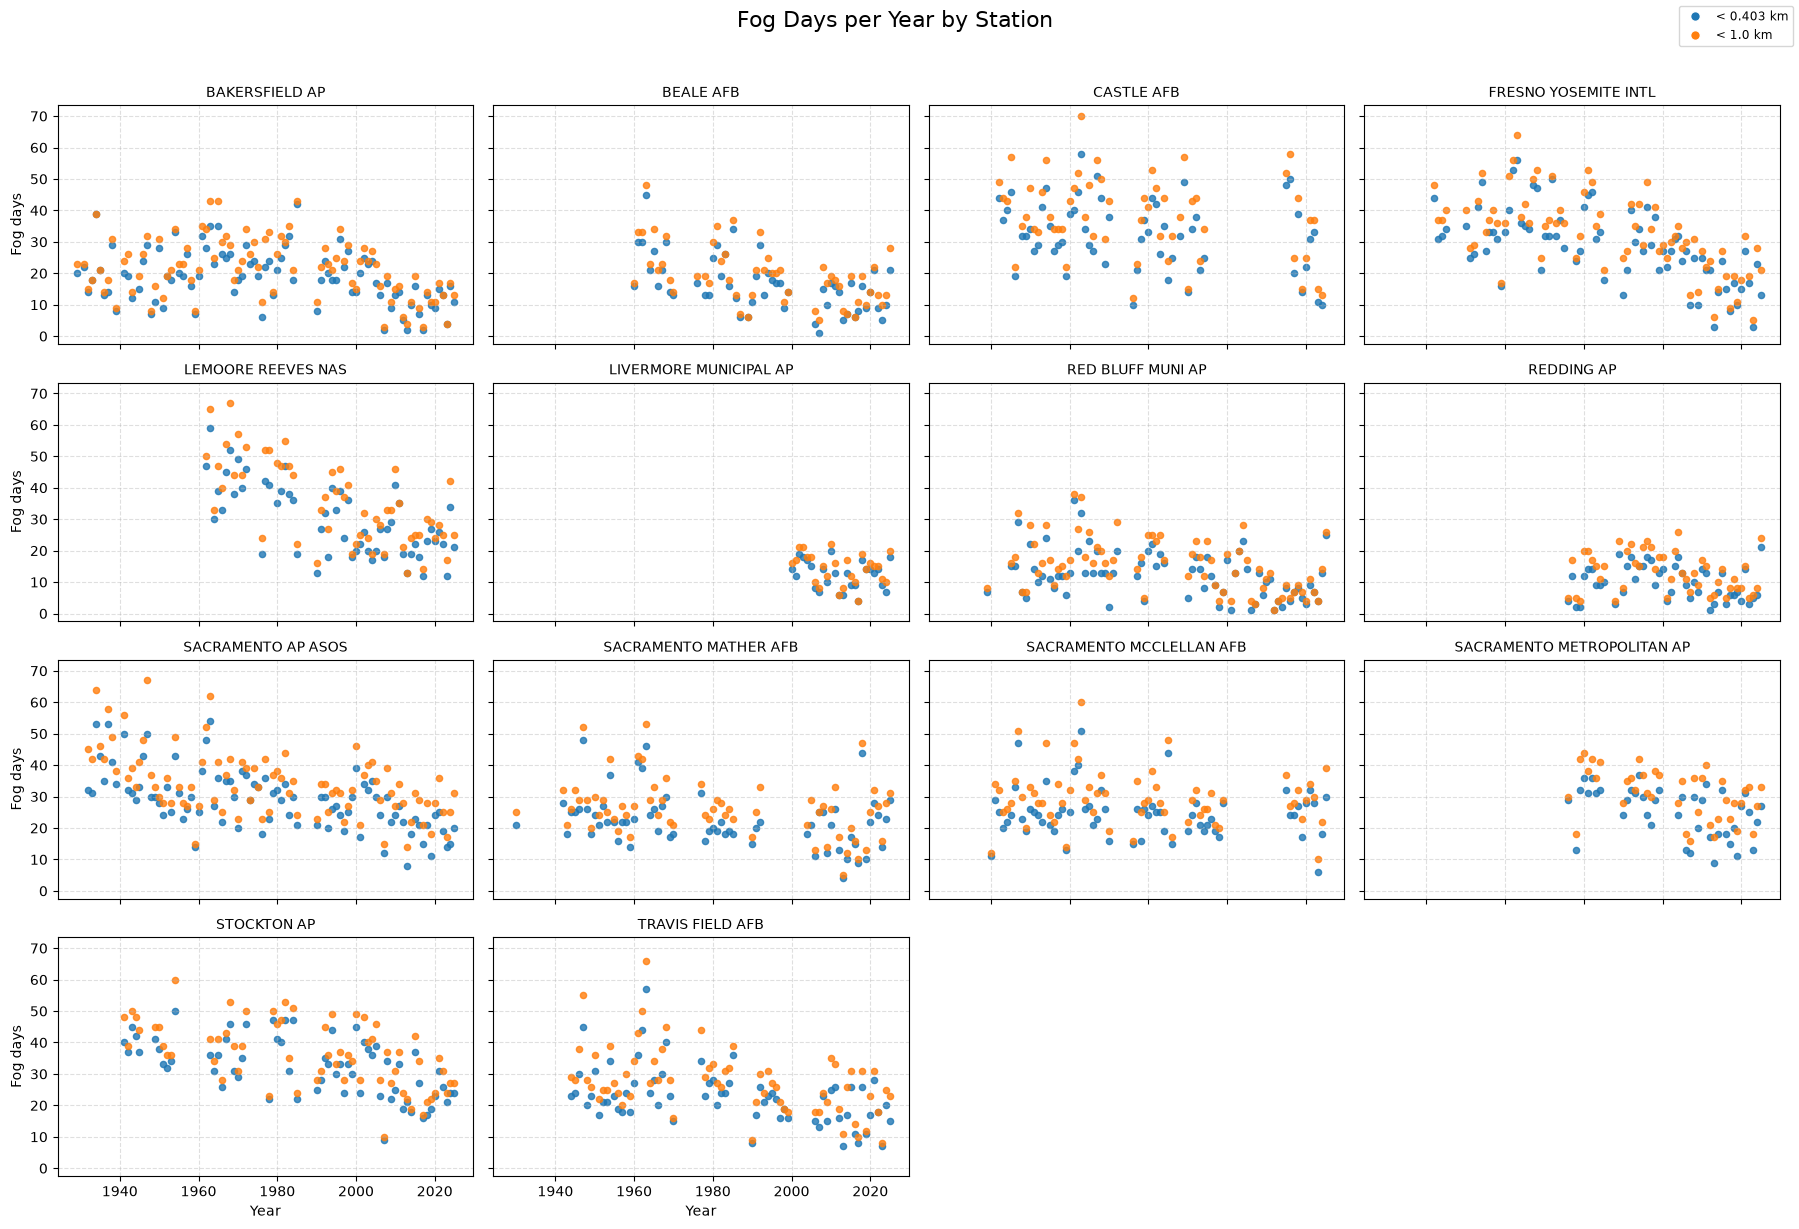

In [19]:
# Determine the unique stations present in both filtered datasets for plotting
# sorted makes it so that the stations are in alphabetical order
stations = sorted(
    set(low_vis_fog_days_year_filtered["STATION"])
    | set(low_vis_fog_days_year_filtered_1km["STATION"])
)

#set number of stations
n_stations = len(stations)
# set number of columns for the subplots
ncols = 4
# Determine number of rows needed for the subplots
nrows = int(np.ceil(n_stations / ncols))

# Make the subplots using rows, columns, and set figure size based on the number of stations
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# flatten axes array to make it easier to iterate over in the loop
axes = axes.flatten()

# Loop through each station and plot the fog days per year for both visibility thresholds
for idx, station in enumerate(stations):
    # Get the current axis for the subplot
    ax = axes[idx]
    # Filter data for the current station
    df_h = low_vis_fog_days_year_filtered[
        low_vis_fog_days_year_filtered["STATION"] == station
    # sort the filtered data by year
    ].sort_values("year")
    # Filter station data for the 1km visibility threshold
    df_1km = low_vis_fog_days_year_filtered_1km[
        low_vis_fog_days_year_filtered_1km["STATION"] == station
    # sort the filtered data by year
    ].sort_values("year")

# If the df is not empty, plot the data for the < 0.403 km visibility threshold
    if not df_h.empty:
        # make the plot a scatter plot with year on the x-axis and fog_days on the y-axis
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            # set size of points to 20
            s=20,
            # set the transparency of the points to 0.8
            alpha=0.8,
            # make the color of the points blue
            color="tab:blue",
            # label blue points for the legend
            label="< 0.403 km"
        )
# If the df is not empty, plot the data for the < 1.0 km visibility threshold
    if not df_1km.empty:
        # make the plot a scatter plot with year on the x-axis and fog_days on the y-axis
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            # set size of points to 20
            s=20,
            # set the transparency of the points to 0.8
            alpha=0.8,
            # make the color of the points orange
            color="tab:orange",
            # label orange points for the legend
            label="< 1.0 km"
        )

# Set the title for each subplot to the station name and set font size
    ax.set_title(station, fontsize=10)
    # Make the grid for each plot have dashed lines and set transparency
    ax.grid(True, linestyle="--", alpha=0.4)

# if the subplot is in the first column, set the y-axis label to "Fog days"
    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
# If the subplot is in the last row, set the x-axis label to "Year"
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

# For station axes not in the first column or last row, remove them from the figure
for ax in axes[n_stations:]:
    fig.delaxes(ax)

# Add a legend
handles = [
    # create a legend entry for the blue points representing < 0.403 km visibility
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=7),
    # create a legend entry for the orange points representing < 1.0 km visibility
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", markersize=7),
]
# add the legend in the upper right corner of the figure with a small font size
fig.legend(handles, ["< 0.403 km", "< 1.0 km"], loc="upper right", fontsize="small")

# Set the overall title for the figure and adjust layout
fig.suptitle("Fog Days per Year by Station", fontsize=16, y=1.02)
# use tight_layout to remove excessive space between subplots 
plt.tight_layout()
plt.show()

BREAK --- trends with all days

In [20]:
# Filter for all low visibility fog days
allyears_low_vis = low_vis_fog_days_year_filtered.copy()

# Create empty list to hold trend statistics
trend_stats_low_vis = []

# Loop through each station in all low visibility fog days
for station, station_df in allyears_low_vis.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

    # Use statsmodels to fit a line to each set of station data,
    # Ordinary Least Squares (OLS) regression is used to find the line of best fit
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list. Include...
    trend_stats_low_vis.append({
        # Station 
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values
trend_stats_low_vis = pd.DataFrame(trend_stats_low_vis).sort_values("p_value")

# Show what's being printed
print("All low-visibility fog-day trend statistics by station:")
# print all rows of the trend statistics DataFrame
print(trend_stats_low_vis[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics DataFrame to include only stations with significant trends (p < 0.05)
significant_low_vis = trend_stats_low_vis[trend_stats_low_vis["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics
print(f"\nStations with significant low-visibility fog-day trends: {len(significant_low_vis)}")
# print the first 10 rows of the significant trends DataFrame
print(significant_low_vis[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the low visibility fog days by year to analyze overall trends across all stations
annual_low_vis = (
    # Starting from the fog days with less than < 1km visibility for all years
    allyears_low_vis
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated low visibility fog days
# in order to analyze the overall trend across all stations
model_annual_low_vis = smf.ols("fog_days ~ year", data=annual_low_vis).fit()

print("\nAnnual aggregated low-visibility fog-day trend summary:")
print(model_annual_low_vis.summary())

# this cell is for the 0.403 km visibility threshold

All low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
8           SACRAMENTO AP ASOS     89      1932      2025 -0.210598  0.029265   
3         FRESNO YOSEMITE INTL     74      1942      2025 -0.293252  0.044074   
4           LEMOORE REEVES NAS     56      1962      2025 -0.399008  0.059676   
12                 STOCKTON AP     65      1941      2025 -0.207655  0.038013   
1                    BEALE AFB     53      1960      2025 -0.233709  0.050482   
13            TRAVIS FIELD AFB     66      1944      2025 -0.163203  0.038926   
0               BAKERSFIELD AP     90      1929      2025 -0.100869  0.030212   
6            RED BLUFF MUNI AP     73      1939      2025 -0.106840  0.033012   
11  SACRAMENTO METROPOLITAN AP     40      1976      2025 -0.232937  0.076046   
9        SACRAMENTO MATHER AFB     64      1930      2025 -0.098490  0.037008   
2                   CASTLE AFB     56      1942      

In [21]:
# Filter for all low visibility fog days
low_vis_1km = low_vis_fog_days_year_filtered_1km.copy()

# Create empty list to hold trend statistics for the 1km visibility threshold
trend_stats_low_vis_1km = []

# Loop through each station in the post-1980 low visibility fog days for the 1km visibility threshold
for station, station_df in low_vis_1km.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

# Use statsmodels to fit a line to each set of station data for the 1km visibility threshold
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list for the 1km visibility threshold. Include...
    trend_stats_low_vis_1km.append({
        # Station
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values for the 1km visibility threshold
trend_stats_low_vis_1km = pd.DataFrame(trend_stats_low_vis_1km).sort_values("p_value")

# Show what's being printed for the 1km visibility threshold
print("Low-visibility fog-day trend statistics by station for the 1km visibility threshold:")
# print all rows of the trend statistics DataFrame for the 1km visibility threshold
print(trend_stats_low_vis_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics to include only stations with significant trends (p < 0.05) for < 1km visibility
significant_low_vis_1km = trend_stats_low_vis_1km[trend_stats_low_vis_1km["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics for the 1km visibility threshold
print(f"\nStations with significant low-visibility fog-day trends for the 1km visibility threshold: {len(significant_low_vis_1km)}")
# print the first 10 rows of the significant trends DataFrame for the 1km visibility threshold
print(significant_low_vis_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the low visibility fog days by year to analyze overall trends across all stations for the 1km visibility threshold
annual_low_vis_1km = (
    # Starting from the fog days with less than < 1km visibility for all years
    low_vis_1km
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated low visibility fog days for the 1km visibility threshold
# in order to analyze the overall trend across all stations
model_annual_low_vis_1km = smf.ols("fog_days ~ year", data=annual_low_vis_1km).fit()

# print the summary of the annual aggregated low-visibility fog-day trend for the 1km visibility threshold
print("\nAnnual aggregated low-visibility fog-day trend summary for the 1km visibility threshold:")
print(model_annual_low_vis_1km.summary())

# this cell is for the 1km visibility threshold

Low-visibility fog-day trend statistics by station for the 1km visibility threshold:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     74      1942      2025 -0.313078  0.046306   
4           LEMOORE REEVES NAS     56      1962      2025 -0.478385  0.068870   
8           SACRAMENTO AP ASOS     89      1932      2025 -0.204479  0.034483   
12                 STOCKTON AP     65      1941      2025 -0.230393  0.043435   
1                    BEALE AFB     53      1960      2025 -0.238049  0.054303   
13            TRAVIS FIELD AFB     66      1944      2025 -0.188769  0.045029   
6            RED BLUFF MUNI AP     73      1939      2025 -0.145248  0.035950   
0               BAKERSFIELD AP     90      1929      2025 -0.108761  0.033270   
11  SACRAMENTO METROPOLITAN AP     40      1976      2025 -0.240136  0.076242   
9        SACRAMENTO MATHER AFB     64      1930      2025 -0.107004  0.039458   
2                   CAST

In [22]:
# make a list of stations with significant trends for heavy fog days after 1980 (< 0.403 km visibility)
stations_significant_low_vis = significant_low_vis.loc[
    significant_low_vis["trend_significant"], "STATION"
].tolist()

print("Significant low-visibility fog-day trend stations:")
print(stations_significant_low_vis)

Significant low-visibility fog-day trend stations:
['SACRAMENTO AP ASOS', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'STOCKTON AP', 'BEALE AFB', 'TRAVIS FIELD AFB', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'SACRAMENTO METROPOLITAN AP', 'SACRAMENTO MATHER AFB', 'CASTLE AFB']


In [23]:
# make a list of stations with significant trends for fog days after 1980 (< 1 km visibility)
stations_significant_low_vis_1km = significant_low_vis_1km.loc[
    significant_low_vis_1km["trend_significant"], "STATION"
].tolist()

print("Significant low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_1km)

Significant low-visibility (<1km) fog-day trend stations:
['FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'SACRAMENTO AP ASOS', 'STOCKTON AP', 'BEALE AFB', 'TRAVIS FIELD AFB', 'RED BLUFF MUNI AP', 'BAKERSFIELD AP', 'SACRAMENTO METROPOLITAN AP', 'SACRAMENTO MATHER AFB', 'CASTLE AFB']


In [24]:
# Using stations with significant trends for heavy fog days after 1980 (< 0.403 km vis)...
stations = stations_significant_low_vis

# # Using stations with significant trends for fog days after 1980 (< 1 km vis)...
all_h = low_vis_fog_days_year_filtered

all_1km = low_vis_fog_days_year_filtered_1km

In [25]:
# Plot scatterplots with all points per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig_all = set(stations_significant_low_vis)      # <0.403 km significant
stations_1km_sig_all = set(stations_significant_low_vis_1km)  # <1.0 km significant

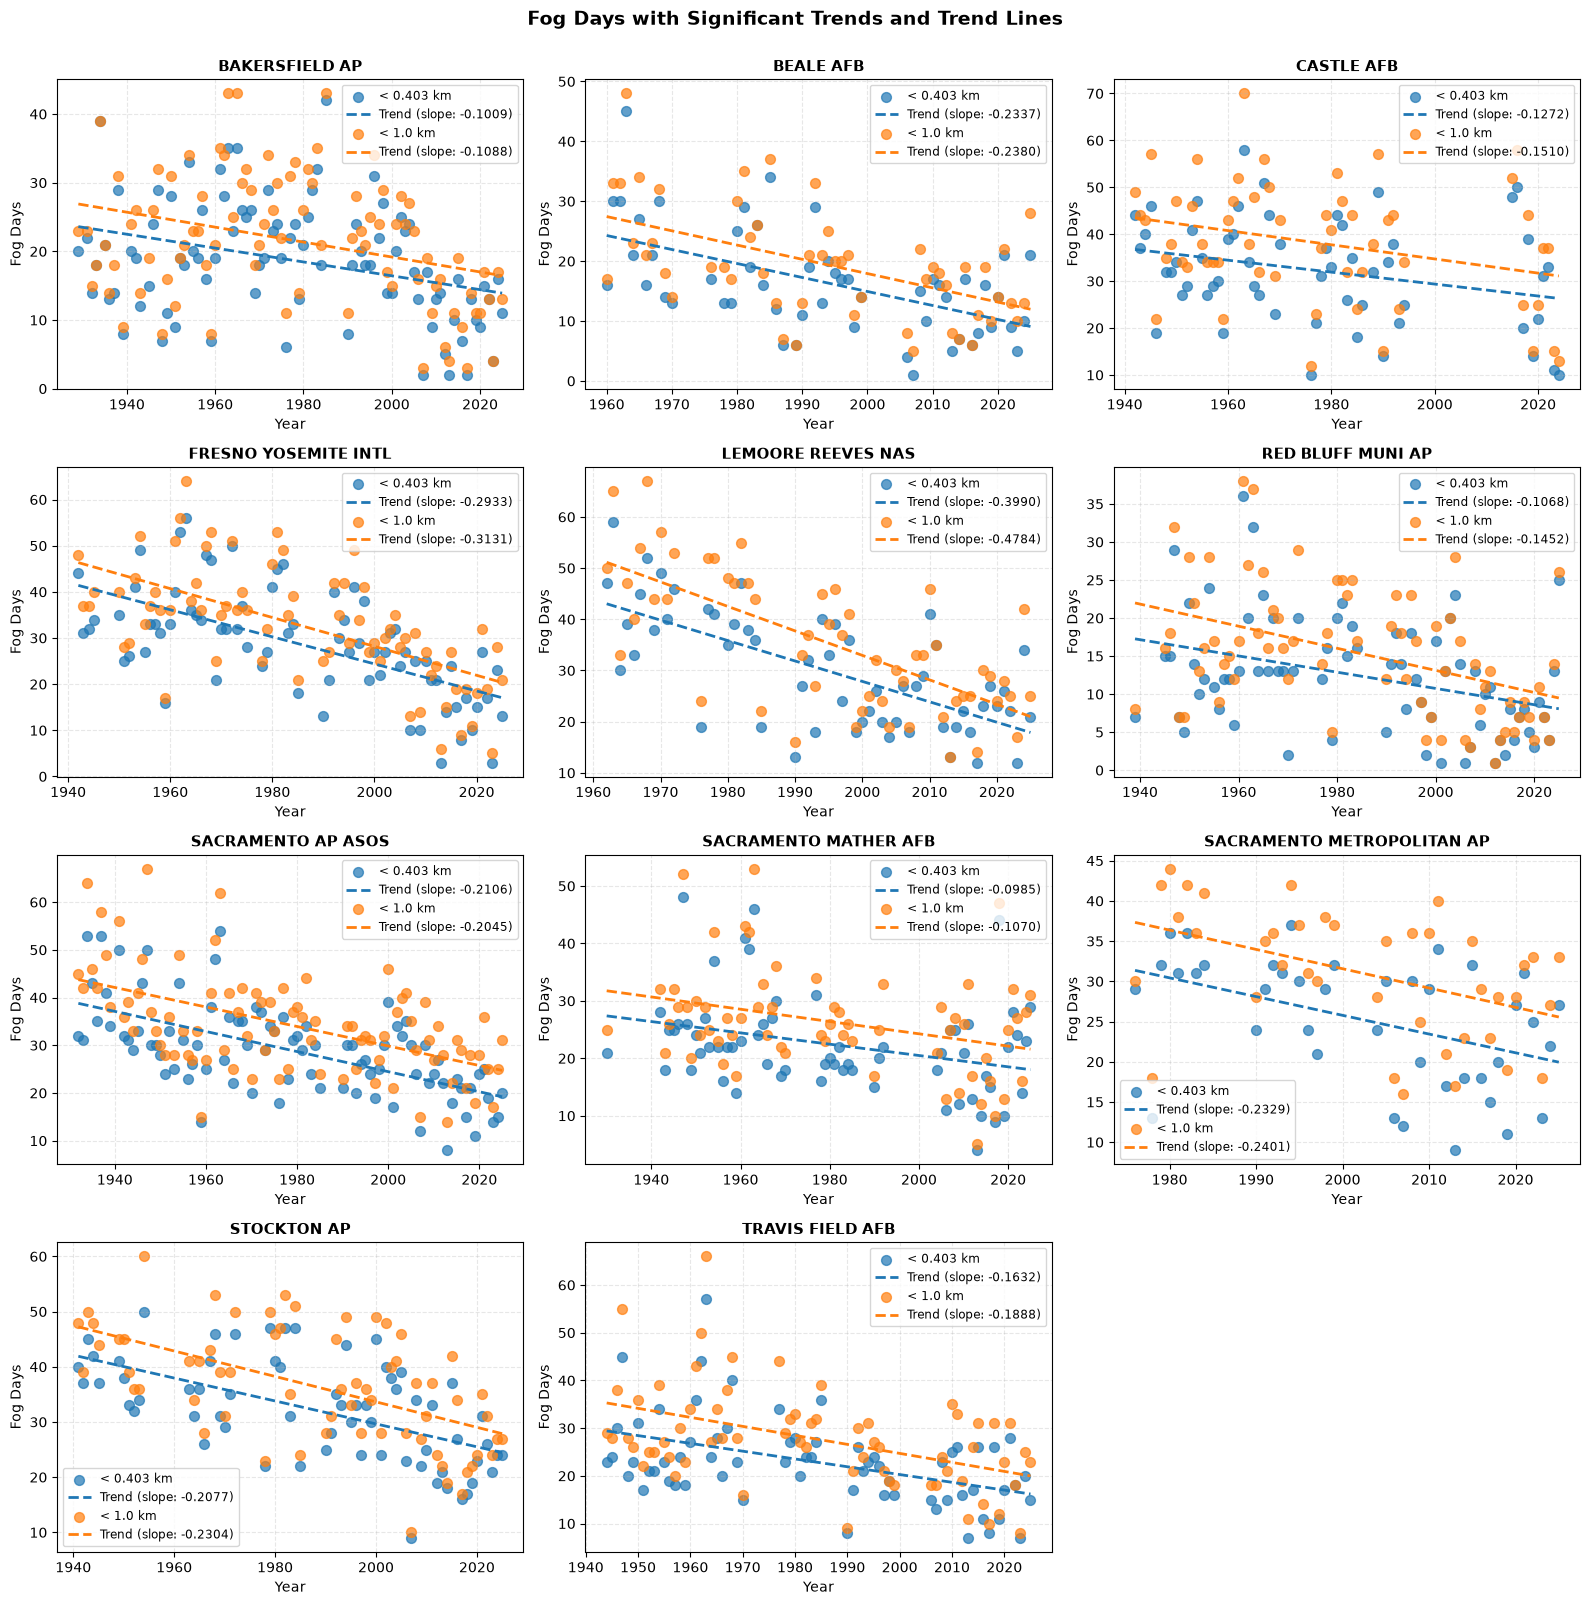

In [26]:
# Create scatterplots with trend lines for stations with significant trends
# determine stations to plot by taking the union of stations with significant trends for both thresholds
stations_to_plot = sorted(stations_h_sig_all | stations_1km_sig_all)
# set up how many stations
n_stations = len(stations_to_plot)
# number of columns
ncols = 3
# how many rows are needed
nrows = int(np.ceil(n_stations / ncols))

# Create subplots for each station with significant trends
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
# flatten the axes array to make it easier to iterate over in the loop
axes = axes.flatten()

# loop through each station to plot
for idx, station in enumerate(stations_to_plot):
    # get the current axis for the subplot (what figure is being plotted)
    ax = axes[idx]
    # check if the station has significant trends for either threshold
    sig_h = station in stations_h_sig_all
    sig_1km = station in stations_1km_sig_all

    # Filter the post-1980 data for the current station and sort by year
    df_h = all_h[all_h["STATION"] == station].sort_values("year")
    df_1km = all_1km[all_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 0.403 km visibility
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        # fit a trend line
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        # get the slope of the trend line
        slope_h = model_h.params["year"]
        # predict the trend line values using the fitted model
        trend_line_h = model_h.predict(df_h)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 1.0 km visibility
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        # fit a trend line
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        # get the slope of the trend line
        slope_1km = model_1km.params["year"]
        # predict the trend line values using the fitted model
        trend_line_1km = model_1km.predict(df_1km)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")

    # Make title for each subplot
    ax.set_title(station, fontsize=11, fontweight="bold")
    # Set x and y labels
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    # Make the grid for each plot have dashed lines and set transparency
    ax.grid(True, linestyle="--", alpha=0.3)
    # Add a legend to each subplot with a small font size and best location
    ax.legend(fontsize="small", loc="best")

# Remove unused subplot axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

# Title entire figure and adjust layout
fig.suptitle("Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

BREAK --- trends since 1980

In [27]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

# Create empty list to hold trend statistics
trend_stats_low_vis_post1980 = []

# Loop through each station in the post-1980 low visibility fog days
for station, station_df in post1980_low_vis.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

    # Use statsmodels to fit a line to each set of station data,
    # Ordinary Least Squares (OLS) regression is used to find the line of best fit
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list. Include...
    trend_stats_low_vis_post1980.append({
        # Station 
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values
trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

# Show what's being printed
print("Post-1980 low-visibility fog-day trend statistics by station:")
# print all rows of the trend statistics DataFrame
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics DataFrame to include only stations with significant trends (p < 0.05)
significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
# print the first 10 rows of the significant trends DataFrame
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the post-1980 low visibility fog days by year to analyze overall trends across all stations
annual_low_vis_post1980 = (
    # Starting from the fog days with less than < 1km visibility for years after 1980
    post1980_low_vis
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated post-1980 low visibility fog days
# in order to analyze the overall trend across all stations
model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

# this cell is for the 0.403 km visibility threshold

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     42      1980      2025 -0.556802  0.095617   
0               BAKERSFIELD AP     42      1980      2025 -0.441582  0.078241   
12                 STOCKTON AP     42      1980      2025 -0.386109  0.090953   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.309183  0.081108   
8           SACRAMENTO AP ASOS     42      1980      2025 -0.268701  0.071806   
4           LEMOORE REEVES NAS     42      1980      2025 -0.303698  0.096082   
1                    BEALE AFB     39      1980      2025 -0.233360  0.077611   
6            RED BLUFF MUNI AP     41      1980      2025 -0.219296  0.075124   
13            TRAVIS FIELD AFB     36      1980      2025 -0.198706  0.075356   
7                   REDDING AP     44      1980      2025 -0.131098  0.056746   
2                   CASTLE AFB     24      1980

In [28]:
# Filter for low visibility fog days after 1980
post1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] >= 1980].copy()

# Create empty list to hold trend statistics for the 1km visibility threshold
trend_stats_low_vis_post1980_1km = []

# Loop through each station in the post-1980 low visibility fog days for the 1km visibility threshold
for station, station_df in post1980_low_vis_1km.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

# Use statsmodels to fit a line to each set of station data for the 1km visibility threshold
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list for the 1km visibility threshold. Include...
    trend_stats_low_vis_post1980_1km.append({
        # Station
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values for the 1km visibility threshold
trend_stats_low_vis_post1980_1km = pd.DataFrame(trend_stats_low_vis_post1980_1km).sort_values("p_value")

# Show what's being printed for the 1km visibility threshold
print("Post-1980 low-visibility fog-day trend statistics by station:")
# print all rows of the trend statistics DataFrame for the 1km visibility threshold
print(trend_stats_low_vis_post1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics to include only stations with significant trends (p < 0.05) for < 1km visibility
significant_low_vis_post1980_1km = trend_stats_low_vis_post1980_1km[trend_stats_low_vis_post1980_1km["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics for the 1km visibility threshold
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980_1km)}")
# print the first 10 rows of the significant trends DataFrame for the 1km visibility threshold
print(significant_low_vis_post1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the post-1980 low visibility fog days by year to analyze overall trends across all stations for the 1km visibility threshold
annual_low_vis_post1980_1km = (
    # Starting from the fog days with less than < 1km visibility for years after 1980
    post1980_low_vis_1km
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated post-1980 low visibility fog days for the 1km visibility threshold
# in order to analyze the overall trend across all stations
model_annual_low_vis_post1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_post1980_1km).fit()

# print the summary of the annual aggregated post-1980 low-visibility fog-day trend for the 1km visibility threshold
print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980_1km.summary())

# this cell is for the 1km visibility threshold

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.507854  0.078542   
3         FRESNO YOSEMITE INTL     42      1980      2025 -0.621197  0.098549   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.325893  0.078089   
12                 STOCKTON AP     42      1980      2025 -0.424168  0.103200   
6            RED BLUFF MUNI AP     41      1980      2025 -0.328644  0.079811   
4           LEMOORE REEVES NAS     42      1980      2025 -0.415045  0.109994   
7                   REDDING AP     44      1980      2025 -0.193693  0.064957   
1                    BEALE AFB     39      1980      2025 -0.237330  0.085785   
8           SACRAMENTO AP ASOS     42      1980      2025 -0.214834  0.083704   
13            TRAVIS FIELD AFB     36      1980      2025 -0.203646  0.088651   
2                   CASTLE AFB     24      1980

In [29]:
# make a list of stations with significant trends for heavy fog days after 1980 (< 0.403 km visibility)
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'STOCKTON AP', 'SACRAMENTO METROPOLITAN AP', 'SACRAMENTO AP ASOS', 'LEMOORE REEVES NAS', 'BEALE AFB', 'RED BLUFF MUNI AP', 'TRAVIS FIELD AFB', 'REDDING AP']


In [30]:
# make a list of stations with significant trends for fog days after 1980 (< 1 km visibility)
stations_significant_low_vis_post1980_1km = significant_low_vis_post1980_1km.loc[
    significant_low_vis_post1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_post1980_1km)

Significant post-1980 low-visibility (<1km) fog-day trend stations:
['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'RED BLUFF MUNI AP', 'LEMOORE REEVES NAS', 'REDDING AP', 'BEALE AFB', 'SACRAMENTO AP ASOS', 'TRAVIS FIELD AFB']


In [31]:
# Using stations with significant trends for heavy fog days after 1980 (< 0.403 km vis)...
stations = stations_significant_low_vis_post1980

# Using stations with significant trends for fog days after 1980 (< 1 km vis)...
post1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] >= 1980
]
post1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] >= 1980
]

In [32]:
# Plot post-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig = set(stations_significant_low_vis_post1980)      # <0.403 km significant
stations_1km_sig = set(stations_significant_low_vis_post1980_1km)  # <1.0 km significant

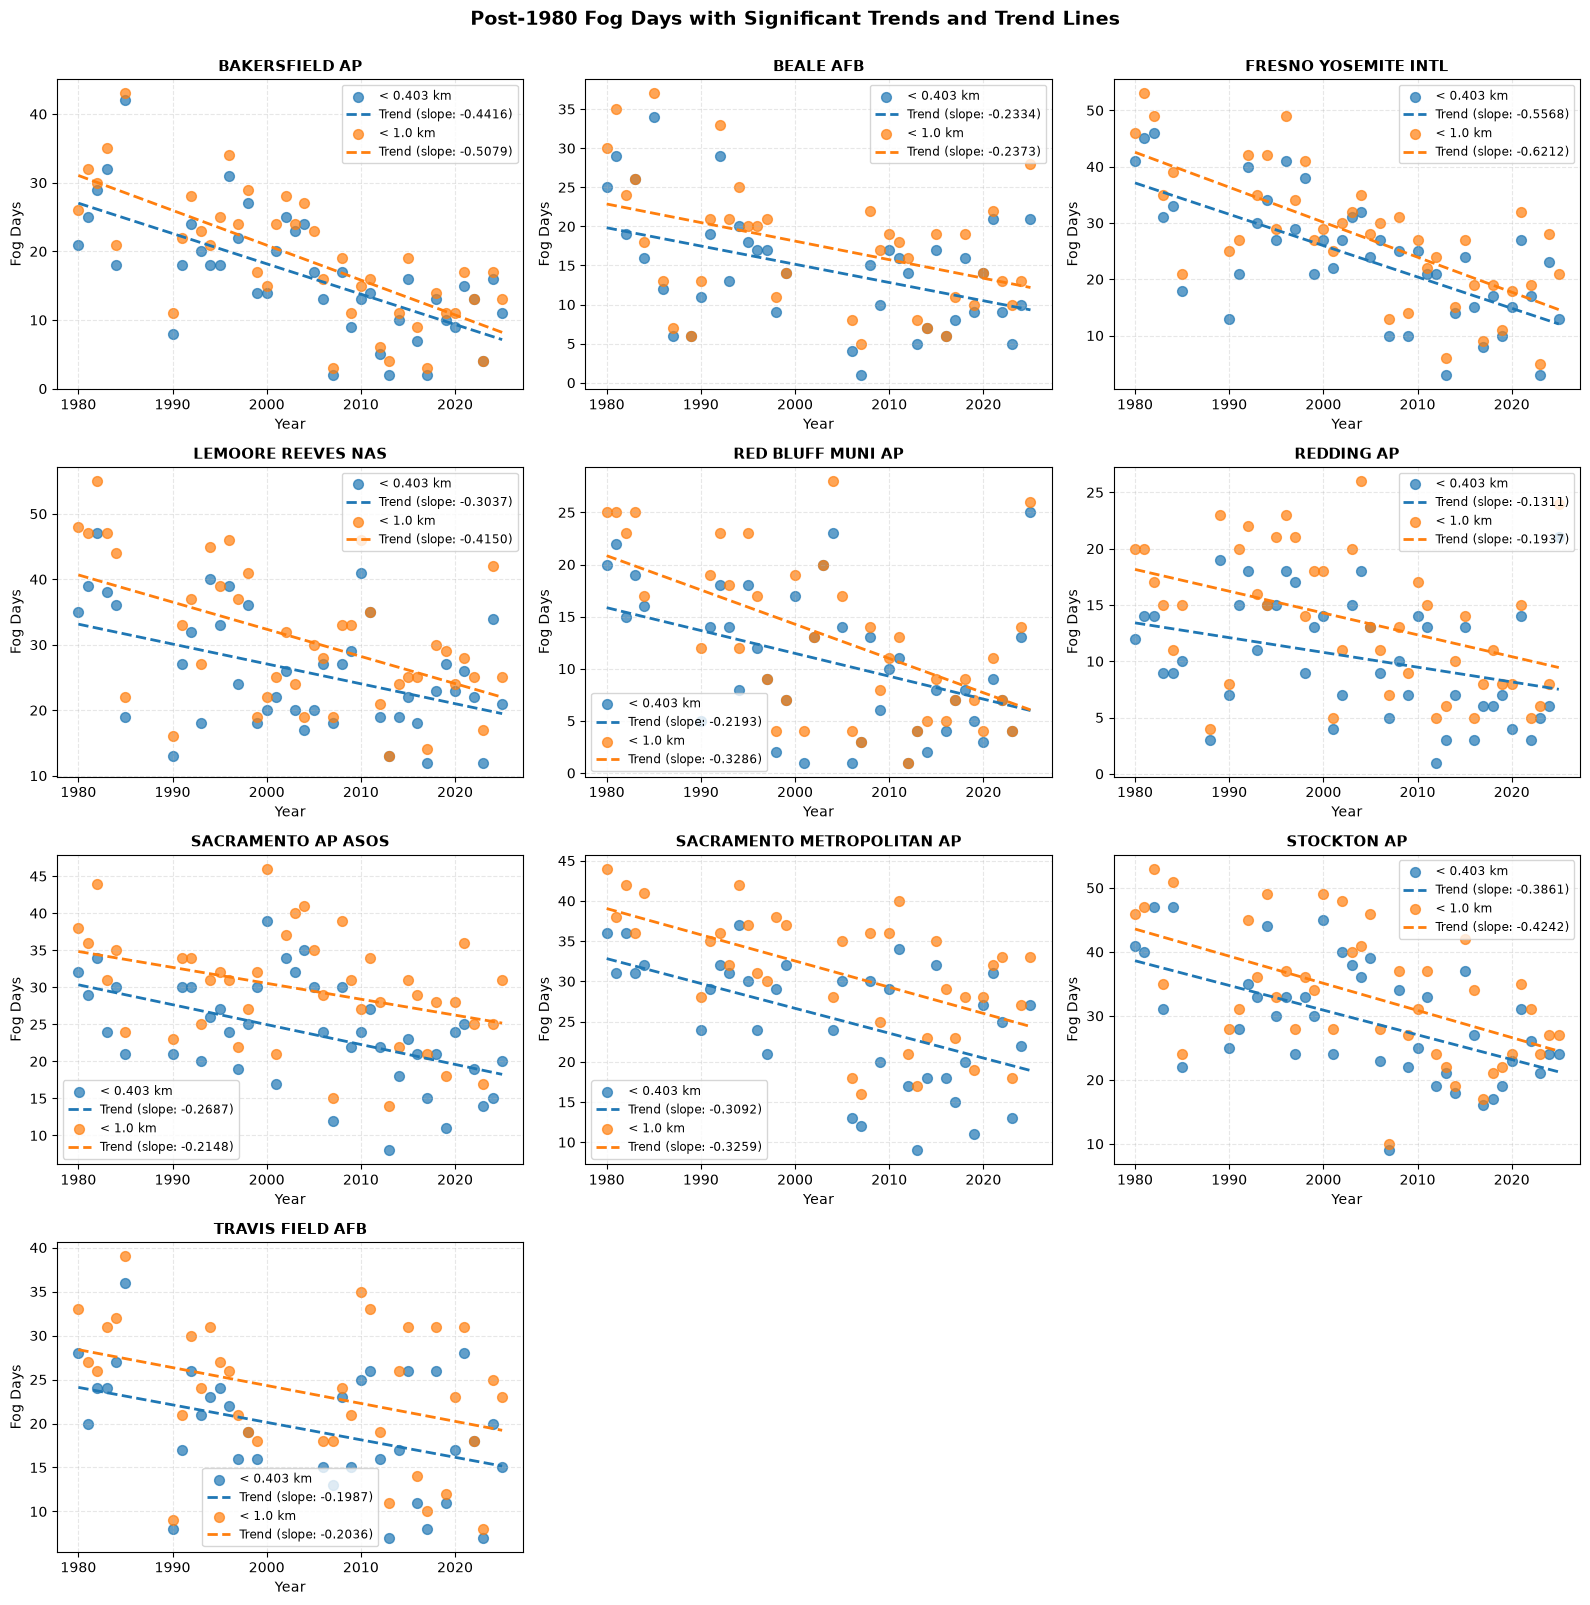

In [33]:
# Create scatterplots with trend lines for stations with significant trends
# determine stations to plot by taking the union of stations with significant trends for both thresholds
stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
# set up how many stations
n_stations = len(stations_to_plot)
# number of columns
ncols = 3
# how many rows are needed
nrows = int(np.ceil(n_stations / ncols))

# Create subplots for each station with significant trends
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
# flatten the axes array to make it easier to iterate over in the loop
axes = axes.flatten()

# loop through each station to plot
for idx, station in enumerate(stations_to_plot):
    # get the current axis for the subplot (what figure is being plotted)
    ax = axes[idx]
    # check if the station has significant trends for either threshold
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig

    # Filter the post-1980 data for the current station and sort by year
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 0.403 km visibility
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        # fit a trend line
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        # get the slope of the trend line
        slope_h = model_h.params["year"]
        # predict the trend line values using the fitted model
        trend_line_h = model_h.predict(df_h)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 1.0 km visibility
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        # fit a trend line
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        # get the slope of the trend line
        slope_1km = model_1km.params["year"]
        # predict the trend line values using the fitted model
        trend_line_1km = model_1km.predict(df_1km)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")

    # Make title for each subplot
    ax.set_title(station, fontsize=11, fontweight="bold")
    # Set x and y labels
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    # Make the grid for each plot have dashed lines and set transparency
    ax.grid(True, linestyle="--", alpha=0.3)
    # Add a legend to each subplot with a small font size and best location
    ax.legend(fontsize="small", loc="best")

# Remove unused subplot axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

# Title entire figure and adjust layout
fig.suptitle("Post-1980 Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

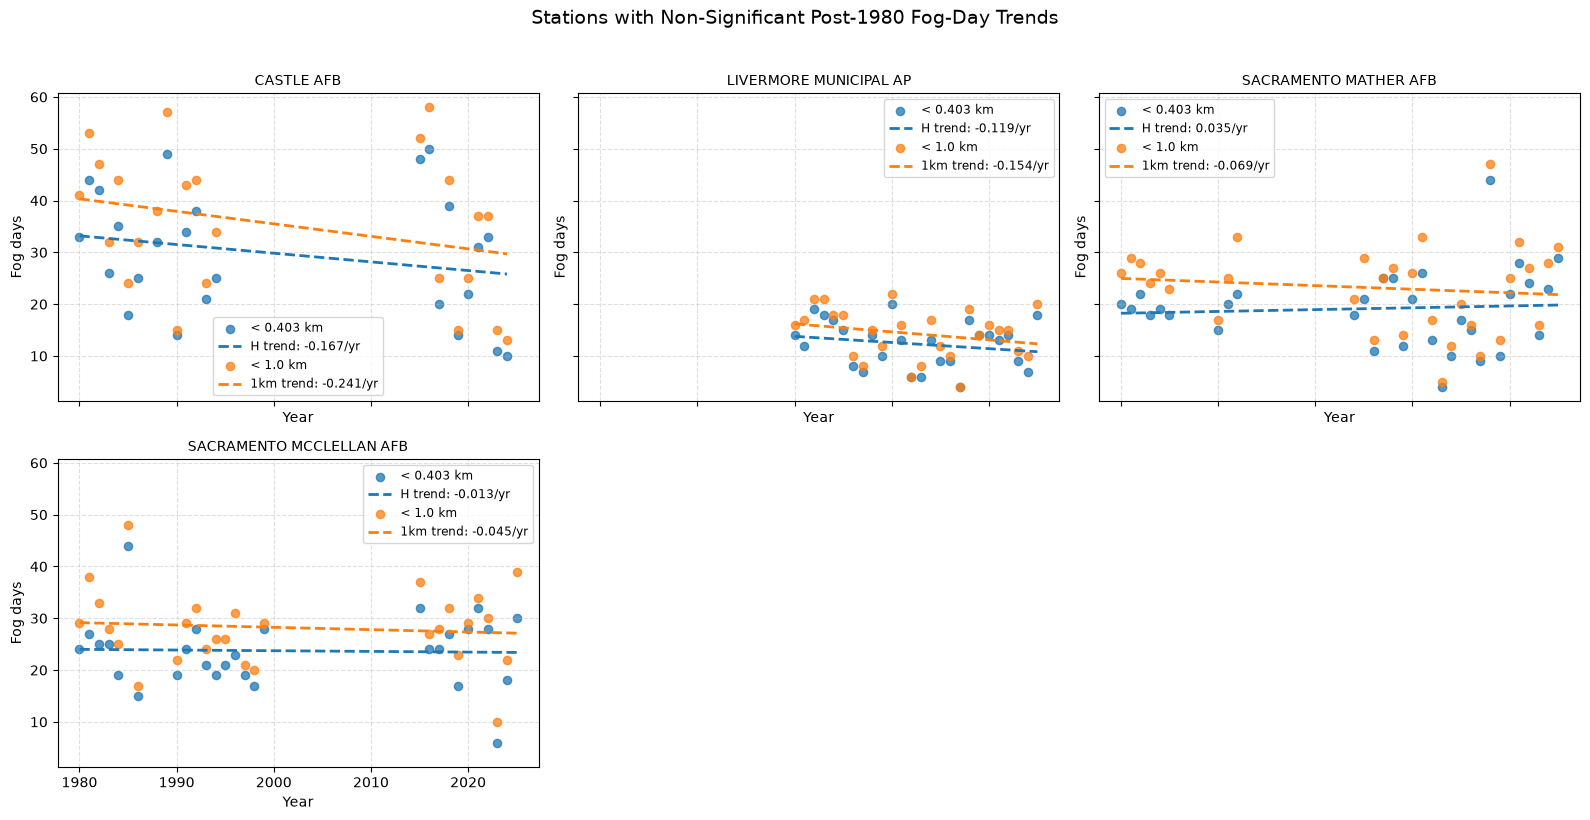

Stations plotted: ['CASTLE AFB', 'LIVERMORE MUNICIPAL AP', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB']


In [34]:
# Plot stations with non-significant post-1980 fog-day trends
# for <0.403 km and <1.0 km visibility thresholds.

nonsig_days_h = trend_stats_low_vis_post1980[
    ~trend_stats_low_vis_post1980["trend_significant"]
].copy()

nonsig_days_1km = trend_stats_low_vis_post1980_1km[
    ~trend_stats_low_vis_post1980_1km["trend_significant"]
].copy()

stations_h_nonsig_days = set(nonsig_days_h["STATION"])
stations_1km_nonsig_days = set(nonsig_days_1km["STATION"])
stations_to_plot_nonsig_days = sorted(
    stations_h_nonsig_days | stations_1km_nonsig_days
)

if not stations_to_plot_nonsig_days:
    print("No non-significant post-1980 station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nonsig_days) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(16, nrows * 4), sharex=True, sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nonsig_days):
        ax = axes[idx]

        df_h = post1980_h[
            post1980_h["STATION"] == station
        ].sort_values("year")

        df_1km = post1980_1km[
            post1980_1km["STATION"] == station
        ].sort_values("year")

        if station in stations_h_nonsig_days and not df_h.empty:
            model_h = smf.ols("fog_days ~ year", data=df_h).fit()
            ax.scatter(
                df_h["year"], df_h["fog_days"],
                color="tab:blue", alpha=0.75, s=35,
                label="< 0.403 km"
            )
            ax.plot(
                df_h["year"], model_h.predict(df_h),
                color="tab:blue", linestyle="--", linewidth=2,
                label=f"H trend: {model_h.params['year']:.3f}/yr"
            )

        if station in stations_1km_nonsig_days and not df_1km.empty:
            model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
            ax.scatter(
                df_1km["year"], df_1km["fog_days"],
                color="tab:orange", alpha=0.75, s=35,
                label="< 1.0 km"
            )
            ax.plot(
                df_1km["year"], model_1km.predict(df_1km),
                color="tab:orange", linestyle="--", linewidth=2,
                label=f"1km trend: {model_1km.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog days")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nonsig_days):]:
        fig.delaxes(ax)

    fig.suptitle(
        "Stations with Non-Significant Post-1980 Fog-Day Trends",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

    print("Stations plotted:", stations_to_plot_nonsig_days)

BREAK --- trends pre-1980

In [35]:
# Filter for low visibility fog days before 1980
pre1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] < 1980].copy()

# Create empty list to hold trend statistics
trend_stats_low_vis_pre1980 = []

# Loop through each station in the pre-1980 low visibility fog days
for station, station_df in pre1980_low_vis.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

    # Use statsmodels to fit a line to each set of station data,
    # Ordinary Least Squares (OLS) regression is used to find the line of best fit
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list. Include...
    trend_stats_low_vis_pre1980.append({
        # Station 
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values
trend_stats_low_vis_pre1980 = pd.DataFrame(trend_stats_low_vis_pre1980).sort_values("p_value")

# Show what's being printed
print("Pre-1980 low-visibility fog-day trend statistics by station:")
# print all rows of the trend statistics DataFrame
print(trend_stats_low_vis_pre1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics DataFrame to include only stations with significant trends (p < 0.05)
significant_low_vis_pre1980 = trend_stats_low_vis_pre1980[trend_stats_low_vis_pre1980["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics
print(f"\nStations with significant pre-1980 low-visibility fog-day trends: {len(significant_low_vis_pre1980)}")
# print the first 10 rows of the significant trends DataFrame
print(significant_low_vis_pre1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the pre-1980 low visibility fog days by year to analyze overall trends across all stations
annual_low_vis_pre1980 = (
    # Starting from the fog days with less than < 1km visibility for years before 1980
    pre1980_low_vis
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated pre-1980 low visibility fog days
# in order to analyze the overall trend across all stations
model_annual_low_vis_pre1980 = smf.ols("fog_days ~ year", data=annual_low_vis_pre1980).fit()

print("\nAnnual aggregated pre-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_pre1980.summary())

# this cell is for the 0.403 km visibility threshold

Pre-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
7           SACRAMENTO AP ASOS     47      1932      1979 -0.224247  0.093438   
1                    BEALE AFB     14      1960      1979 -0.861449  0.364545   
4           LEMOORE REEVES NAS     14      1962      1978 -0.597781  0.523425   
11                 STOCKTON AP     23      1941      1979 -0.133862  0.124296   
2                   CASTLE AFB     32      1942      1979 -0.179709  0.172916   
0               BAKERSFIELD AP     48      1929      1979  0.055972  0.078364   
6                   REDDING AP      4      1976      1979 -1.600000  2.349468   
12            TRAVIS FIELD AFB     30      1944      1979  0.092239  0.181682   
8        SACRAMENTO MATHER AFB     33      1930      1979 -0.039099  0.133618   
3         FRESNO YOSEMITE INTL     32      1942      1979 -0.030400  0.165409   
9     SACRAMENTO MCCLELLAN AFB     35      1940 

In [36]:
# Filter for low visibility fog days before 1980
pre1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] < 1980].copy()

# Create empty list to hold trend statistics for the 1km visibility threshold
trend_stats_low_vis_pre1980_1km = []

# Loop through each station in the pre-1980 low visibility fog days for the 1km visibility threshold
for station, station_df in pre1980_low_vis_1km.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

# Use statsmodels to fit a line to each set of station data for the 1km visibility threshold
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list for the 1km visibility threshold. Include...
    trend_stats_low_vis_pre1980_1km.append({
        # Station
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values for the 1km visibility threshold
trend_stats_low_vis_pre1980_1km = pd.DataFrame(trend_stats_low_vis_pre1980_1km).sort_values("p_value")

# Show what's being printed for the 1km visibility threshold
print("Pre-1980 low-visibility fog-day trend statistics by station:")
# print all rows of the trend statistics DataFrame for the 1km visibility threshold
print(trend_stats_low_vis_pre1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

# Filter the trend statistics to include only stations with significant trends (p < 0.05) for < 1km visibility
significant_low_vis_pre1980_1km = trend_stats_low_vis_pre1980_1km[trend_stats_low_vis_pre1980_1km["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics for the 1km visibility threshold
print(f"\nStations with significant pre-1980 low-visibility fog-day trends: {len(significant_low_vis_pre1980_1km)}")
# print the first 10 rows of the significant trends DataFrame for the 1km visibility threshold
print(significant_low_vis_pre1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the pre-1980 low visibility fog days by year to analyze overall trends across all stations for the 1km visibility threshold
annual_low_vis_pre1980_1km = (
    # Starting from the fog days with less than < 1km visibility for years before 1980
    pre1980_low_vis_1km
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated pre-1980 low visibility fog days for the 1km visibility threshold
# in order to analyze the overall trend across all stations
model_annual_low_vis_pre1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_pre1980_1km).fit()

# print the summary of the annual aggregated pre-1980 low-visibility fog-day trend for the 1km visibility threshold
print("\nAnnual aggregated pre-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_pre1980_1km.summary())

# this cell is for the 1km visibility threshold

Pre-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
7           SACRAMENTO AP ASOS     47      1932      1979 -0.342338  0.108761   
1                    BEALE AFB     14      1960      1979 -0.788696  0.384496   
0               BAKERSFIELD AP     48      1929      1979  0.140375  0.085208   
11                 STOCKTON AP     23      1941      1979 -0.209649  0.146245   
2                   CASTLE AFB     32      1942      1979 -0.190750  0.200714   
4           LEMOORE REEVES NAS     14      1962      1978 -0.372227  0.632768   
12            TRAVIS FIELD AFB     30      1944      1979  0.105663  0.208433   
6                   REDDING AP      4      1976      1979 -1.500000  3.217142   
3         FRESNO YOSEMITE INTL     32      1942      1979 -0.057827  0.173637   
10  SACRAMENTO METROPOLITAN AP      3      1976      1979  2.571429  7.423075   
5            RED BLUFF MUNI AP     32      1939 

In [37]:
# make a list of stations with significant trends for heavy fog days after 1980 (< 0.403 km visibility)
stations_significant_low_vis_pre1980 = significant_low_vis_pre1980.loc[
    significant_low_vis_pre1980["trend_significant"], "STATION"
].tolist()

print("Significant pre-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_pre1980)

Significant pre-1980 low-visibility fog-day trend stations:
['SACRAMENTO AP ASOS', 'BEALE AFB']


In [38]:
# make a list of stations with significant trends for fog days after 1980 (< 1 km visibility)
stations_significant_low_vis_pre1980_1km = significant_low_vis_pre1980_1km.loc[
    significant_low_vis_pre1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant pre-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_pre1980_1km)

Significant pre-1980 low-visibility (<1km) fog-day trend stations:
['SACRAMENTO AP ASOS']


In [39]:
# Using stations with significant trends for heavy fog days before 1980 (< 0.403 km vis)...
stations = stations_significant_low_vis_pre1980

# Using stations with significant trends for fog days before 1980 (< 1 km vis)...
pre1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] < 1980
]
pre1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] < 1980
]

In [40]:
# Plot pre-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig_pre = set(stations_significant_low_vis_pre1980)      # <0.403 km significant
stations_1km_sig_pre = set(stations_significant_low_vis_pre1980_1km)  # <1.0 km significant

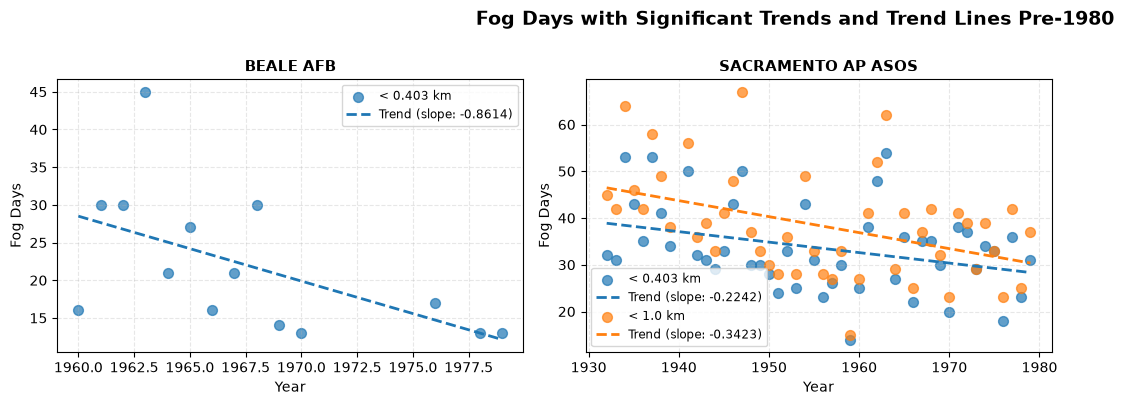

In [41]:
# Create scatterplots with trend lines for stations with significant trends
# determine stations to plot by taking the union of stations with significant trends for both thresholds
stations_to_plot = sorted(stations_h_sig_pre | stations_1km_sig_pre)
# set up how many stations
n_stations = len(stations_to_plot)
# number of columns
ncols = 3
# how many rows are needed
nrows = int(np.ceil(n_stations / ncols))

# Create subplots for each station with significant trends
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
# flatten the axes array to make it easier to iterate over in the loop
axes = axes.flatten()

# loop through each station to plot
for idx, station in enumerate(stations_to_plot):
    # get the current axis for the subplot (what figure is being plotted)
    ax = axes[idx]
    # check if the station has significant trends for either threshold
    sig_h = station in stations_h_sig_pre
    sig_1km = station in stations_1km_sig_pre

    # Filter the post-1980 data for the current station and sort by year
    df_h = pre1980_h[pre1980_h["STATION"] == station].sort_values("year")
    df_1km = pre1980_1km[pre1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 0.403 km visibility
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        # fit a trend line
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        # get the slope of the trend line
        slope_h = model_h.params["year"]
        # predict the trend line values using the fitted model
        trend_line_h = model_h.predict(df_h)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        # make a plot with year on the x-axis and fog_days on the y-axis for < 1.0 km visibility
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        # fit a trend line
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        # get the slope of the trend line
        slope_1km = model_1km.params["year"]
        # predict the trend line values using the fitted model
        trend_line_1km = model_1km.predict(df_1km)
        # plot the trend line on the scatter plot with a dashed line and label it with the slope value
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")

    # Make title for each subplot
    ax.set_title(station, fontsize=11, fontweight="bold")
    # Set x and y labels
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    # Make the grid for each plot have dashed lines and set transparency
    ax.grid(True, linestyle="--", alpha=0.3)
    # Add a legend to each subplot with a small font size and best location
    ax.legend(fontsize="small", loc="best")

# Remove unused subplot axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

# Title entire figure and adjust layout
fig.suptitle("Fog Days with Significant Trends and Trend Lines Pre-1980",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

BREAK - Do the same for fog nights

In [42]:
# Define fog "night" as 18:00-17:59, assigned to the date when the night starts.
# Uses the already-filtered low-visibility fog rows.

# --- <0.403 km threshold ---
night_rows_h = low_vis_rows.copy()
night_rows_h["DATE"] = pd.to_datetime(night_rows_h["DATE"])
night_rows_h["date_only"] = night_rows_h["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis and only stations with at least 30 years of data
# night_rows_h = night_rows_h[night_rows_h["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_h = night_rows_h[night_rows_h["STATION"].isin(CV_filtered_rows_no_outliers["STATION"].unique())].copy()

is_night_h = (night_rows_h["DATE"].dt.hour >= 18) | (night_rows_h["DATE"].dt.hour < 18)

night_rows_h["night_date"] = pd.NaT
night_rows_h.loc[night_rows_h["DATE"].dt.hour >= 18, "night_date"] = night_rows_h["date_only"]
night_rows_h.loc[night_rows_h["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_h["date_only"] - pd.Timedelta(days=1)
)

night_rows_h = night_rows_h[is_night_h].copy()
night_rows_h["night_year"] = night_rows_h["night_date"].dt.year

fog_nights_year_station = (
    night_rows_h.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights = (
    fog_nights_year_station.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("Fog nights per station-year (<0.403 km):")
print(fog_nights_year_station.head())
print("\nAnnual fog nights (<0.403 km):")
print(annual_fog_nights.head())


# --- <1.0 km threshold (optional parallel series) ---
night_rows_1km = low_vis_rows_1km.copy()
night_rows_1km["DATE"] = pd.to_datetime(night_rows_1km["DATE"])
night_rows_1km["date_only"] = night_rows_1km["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis
# night_rows_1km = night_rows_1km[night_rows_1km["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_1km = night_rows_1km[night_rows_1km["STATION"].isin(CV_filtered_rows_no_outliers["STATION"].unique())].copy()

is_night_1km = (night_rows_1km["DATE"].dt.hour >= 18) | (night_rows_1km["DATE"].dt.hour < 18)

night_rows_1km["night_date"] = pd.NaT
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour >= 18, "night_date"] = night_rows_1km["date_only"]
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_1km["date_only"] - pd.Timedelta(days=1)
)

night_rows_1km = night_rows_1km[is_night_1km].copy()
night_rows_1km["night_year"] = night_rows_1km["night_date"].dt.year

fog_nights_year_station_1km = (
    night_rows_1km.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights_1km = (
    fog_nights_year_station_1km.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("\nFog nights per station-year (<1.0 km):")
print(fog_nights_year_station_1km.head())
print("\nAnnual fog nights (<1.0 km):")
print(annual_fog_nights_1km.head())

Fog nights per station-year (<0.403 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1929          19
1  BAKERSFIELD AP  1931          21
2  BAKERSFIELD AP  1932          13
3  BAKERSFIELD AP  1933          18
4  BAKERSFIELD AP  1934          38

Annual fog nights (<0.403 km):
   year  fog_nights
0  1929          20
1  1930          18
2  1931          22
3  1932          44
4  1933          48

Fog nights per station-year (<1.0 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1928           1
1  BAKERSFIELD AP  1929          22
2  BAKERSFIELD AP  1931          23
3  BAKERSFIELD AP  1932          14
4  BAKERSFIELD AP  1933          18

Annual fog nights (<1.0 km):
   year  fog_nights
0  1928           1
1  1929          23
2  1930          23
3  1931          24
4  1932          59


In [43]:
# Determine station-level fog-night trends since 1980
# and plot only significant trends (<0.05 p-value)

trend_stats_nights_h = []
for station, station_df in fog_nights_year_station.groupby("STATION"):
    station_df = station_df.sort_values("year")
    station_df = station_df[station_df["year"] >= 1980]
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_h = pd.DataFrame(trend_stats_nights_h).sort_values("p_value")
significant_nights_h = trend_stats_nights_h[trend_stats_nights_h["trend_significant"]].copy()

print("Significant fog-night trends (<0.403 km):")
print(significant_nights_h[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# Optional parallel analysis for <1.0 km
trend_stats_nights_1km = []
for station, station_df in fog_nights_year_station_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km = pd.DataFrame(trend_stats_nights_1km).sort_values("p_value")
significant_nights_1km = trend_stats_nights_1km[trend_stats_nights_1km["trend_significant"]].copy()

print("\nSignificant fog-night trends (<1.0 km):")
print(significant_nights_1km[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

Significant fog-night trends (<0.403 km):
                       STATION  n_obs     slope       p_value  r_squared
0               BAKERSFIELD AP     42 -0.435851  7.310223e-07   0.462377
3         FRESNO YOSEMITE INTL     42 -0.499272  2.480675e-06   0.429463
11  SACRAMENTO METROPOLITAN AP     37 -0.335853  1.269880e-04   0.346503
8           SACRAMENTO AP ASOS     42 -0.269855  4.906867e-04   0.264709
12                 STOCKTON AP     43 -0.320827  2.838419e-03   0.197399
6            RED BLUFF MUNI AP     41 -0.213496  3.932658e-03   0.194181
4           LEMOORE REEVES NAS     42 -0.270798  6.866929e-03   0.168852
13            TRAVIS FIELD AFB     36 -0.195460  1.739933e-02   0.155298
1                    BEALE AFB     40 -0.191224  1.810141e-02   0.138371
7                   REDDING AP     44 -0.128558  2.431015e-02   0.115030

Significant fog-night trends (<1.0 km):
                       STATION  n_obs     slope   p_value  r_squared
3         FRESNO YOSEMITE INTL     76 -0.2529

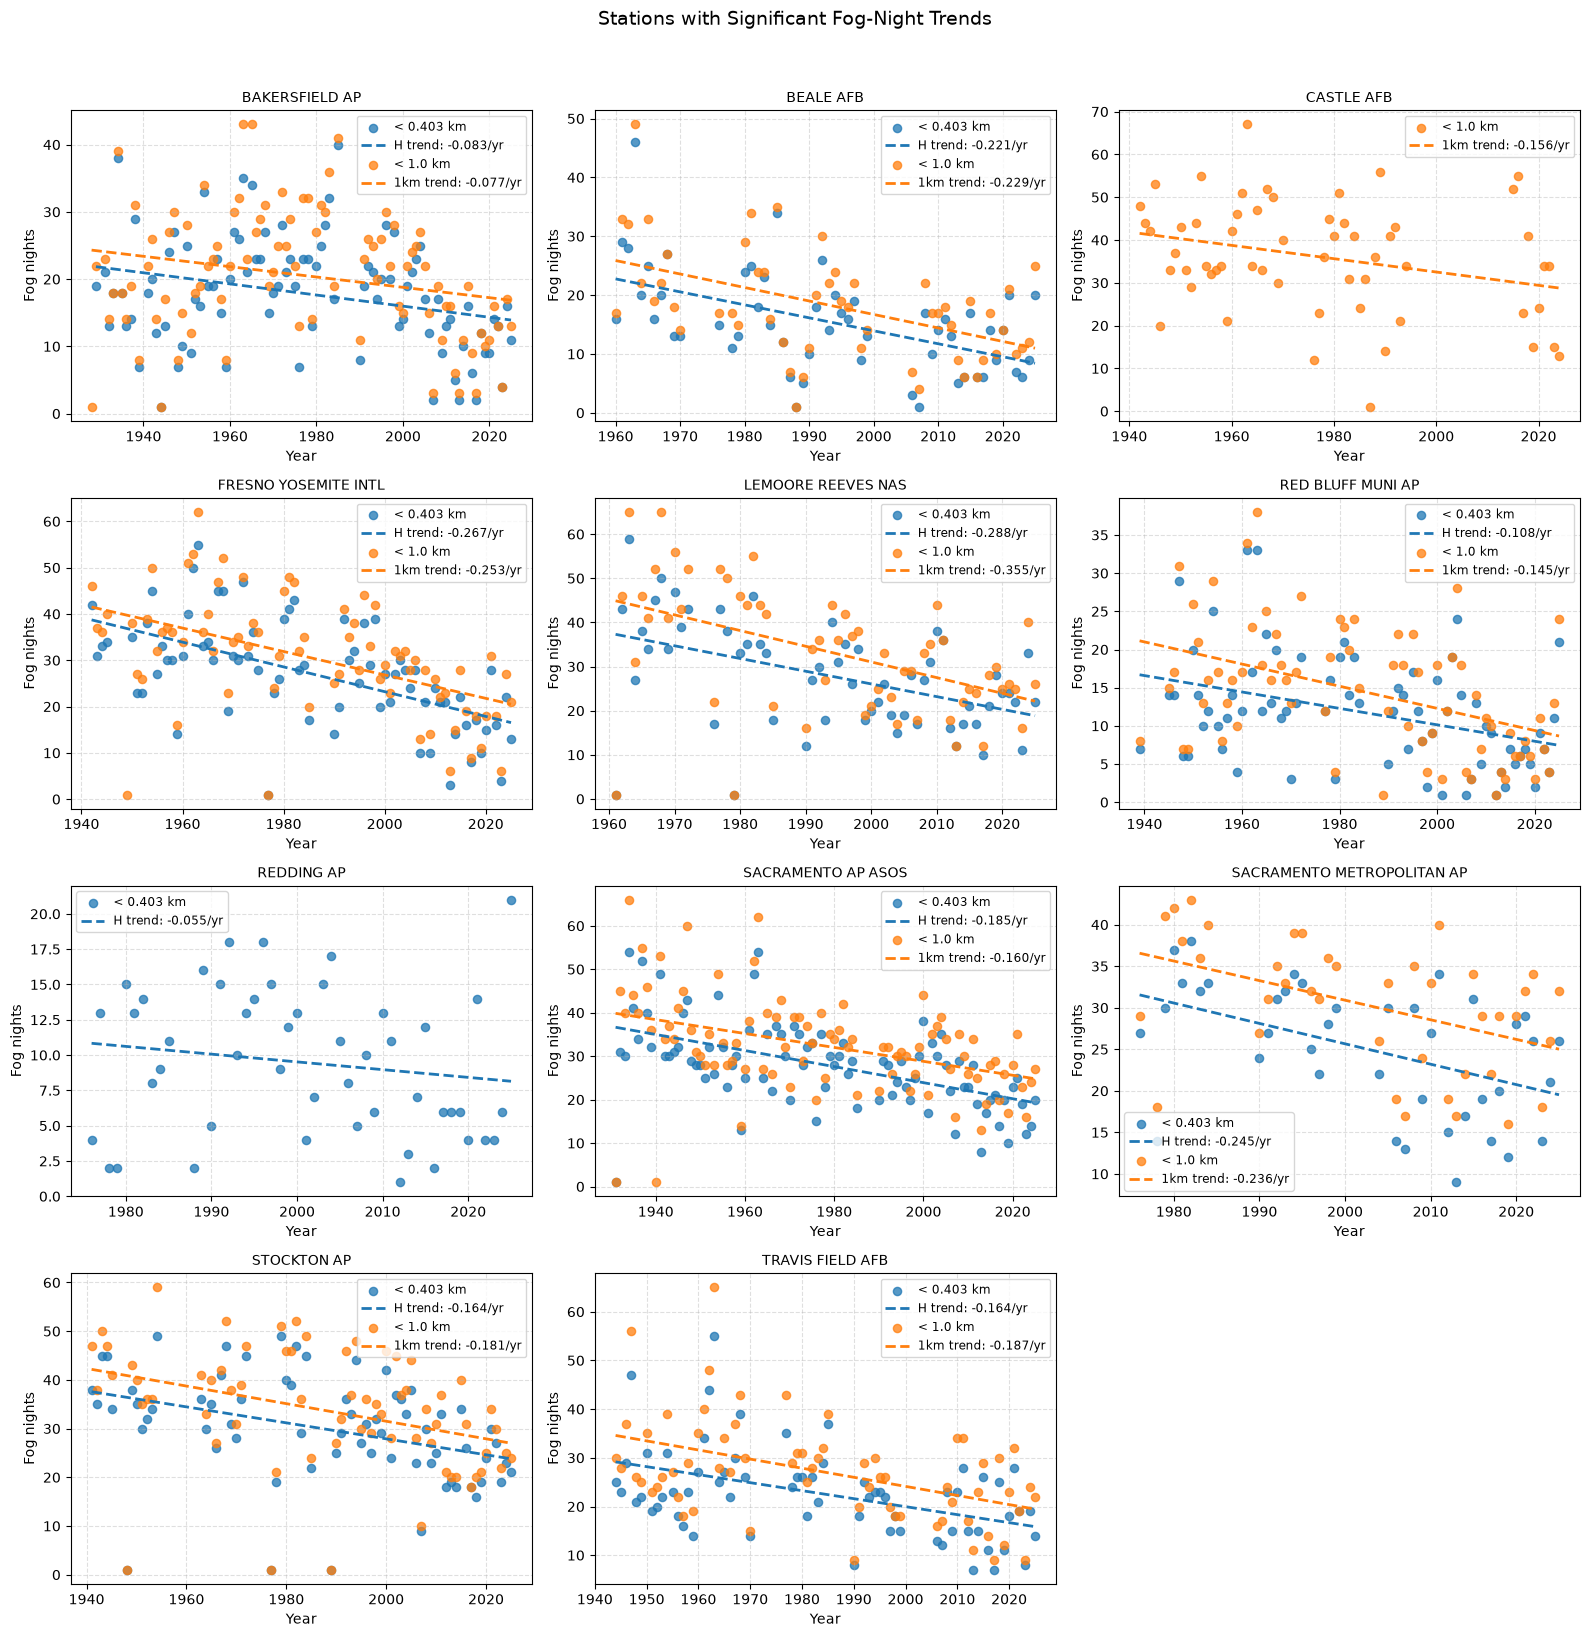

In [44]:
# Plot significant stations with trend lines since 1980 for fog nights (<0.403 km and <1.0 km)

stations_h_sig_nights = set(significant_nights_h["STATION"])
stations_1km_sig_nights = set(significant_nights_1km["STATION"])
stations_to_plot_nights = sorted(stations_h_sig_nights | stations_1km_sig_nights)

if len(stations_to_plot_nights) == 0:
    print("\nNo significant station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights):
        ax = axes[idx]

        df_h = fog_nights_year_station[fog_nights_year_station["STATION"] == station].sort_values("year")
        df_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights and not df_h.empty:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights and not df_1km.empty:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [45]:
# Fog-night trends starting in 1980 only, then plot only significant station trends

post1980_nights_h = fog_nights_year_station[fog_nights_year_station["year"] >= 1980].copy()
post1980_nights_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["year"] >= 1980].copy()

trend_stats_nights_h_post1980 = []
for station, station_df in post1980_nights_h.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_h_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_h_1980.params["year"],
        "intercept": model_h_1980.params["Intercept"],
        "r_squared": model_h_1980.rsquared,
        "p_value": model_h_1980.pvalues["year"],
        "slope_se": model_h_1980.bse["year"],
        "trend_significant": model_h_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_h_post1980 = pd.DataFrame(trend_stats_nights_h_post1980).sort_values("p_value")
significant_nights_h_post1980 = trend_stats_nights_h_post1980[
    trend_stats_nights_h_post1980["trend_significant"]
].copy()

trend_stats_nights_1km_post1980 = []
for station, station_df in post1980_nights_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_1km_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_1km_1980.params["year"],
        "intercept": model_1km_1980.params["Intercept"],
        "r_squared": model_1km_1980.rsquared,
        "p_value": model_1km_1980.pvalues["year"],
        "slope_se": model_1km_1980.bse["year"],
        "trend_significant": model_1km_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km_post1980 = pd.DataFrame(trend_stats_nights_1km_post1980).sort_values("p_value")
significant_nights_1km_post1980 = trend_stats_nights_1km_post1980[
    trend_stats_nights_1km_post1980["trend_significant"]
].copy()

print("Significant post-1980 fog-night trends (<0.403 km):")
print(significant_nights_h_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

print("\nSignificant post-1980 fog-night trends (<1.0 km):")
print(significant_nights_1km_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])


Significant post-1980 fog-night trends (<0.403 km):
                       STATION  n_obs     slope       p_value  r_squared
0               BAKERSFIELD AP     42 -0.435851  7.310223e-07   0.462377
3         FRESNO YOSEMITE INTL     42 -0.499272  2.480675e-06   0.429463
11  SACRAMENTO METROPOLITAN AP     37 -0.335853  1.269880e-04   0.346503
8           SACRAMENTO AP ASOS     42 -0.269855  4.906867e-04   0.264709
12                 STOCKTON AP     43 -0.320827  2.838419e-03   0.197399
6            RED BLUFF MUNI AP     41 -0.213496  3.932658e-03   0.194181
4           LEMOORE REEVES NAS     42 -0.270798  6.866929e-03   0.168852
13            TRAVIS FIELD AFB     36 -0.195460  1.739933e-02   0.155298
1                    BEALE AFB     40 -0.191224  1.810141e-02   0.138371
7                   REDDING AP     44 -0.128558  2.431015e-02   0.115030

Significant post-1980 fog-night trends (<1.0 km):
                       STATION  n_obs     slope       p_value  r_squared
0               BAKER

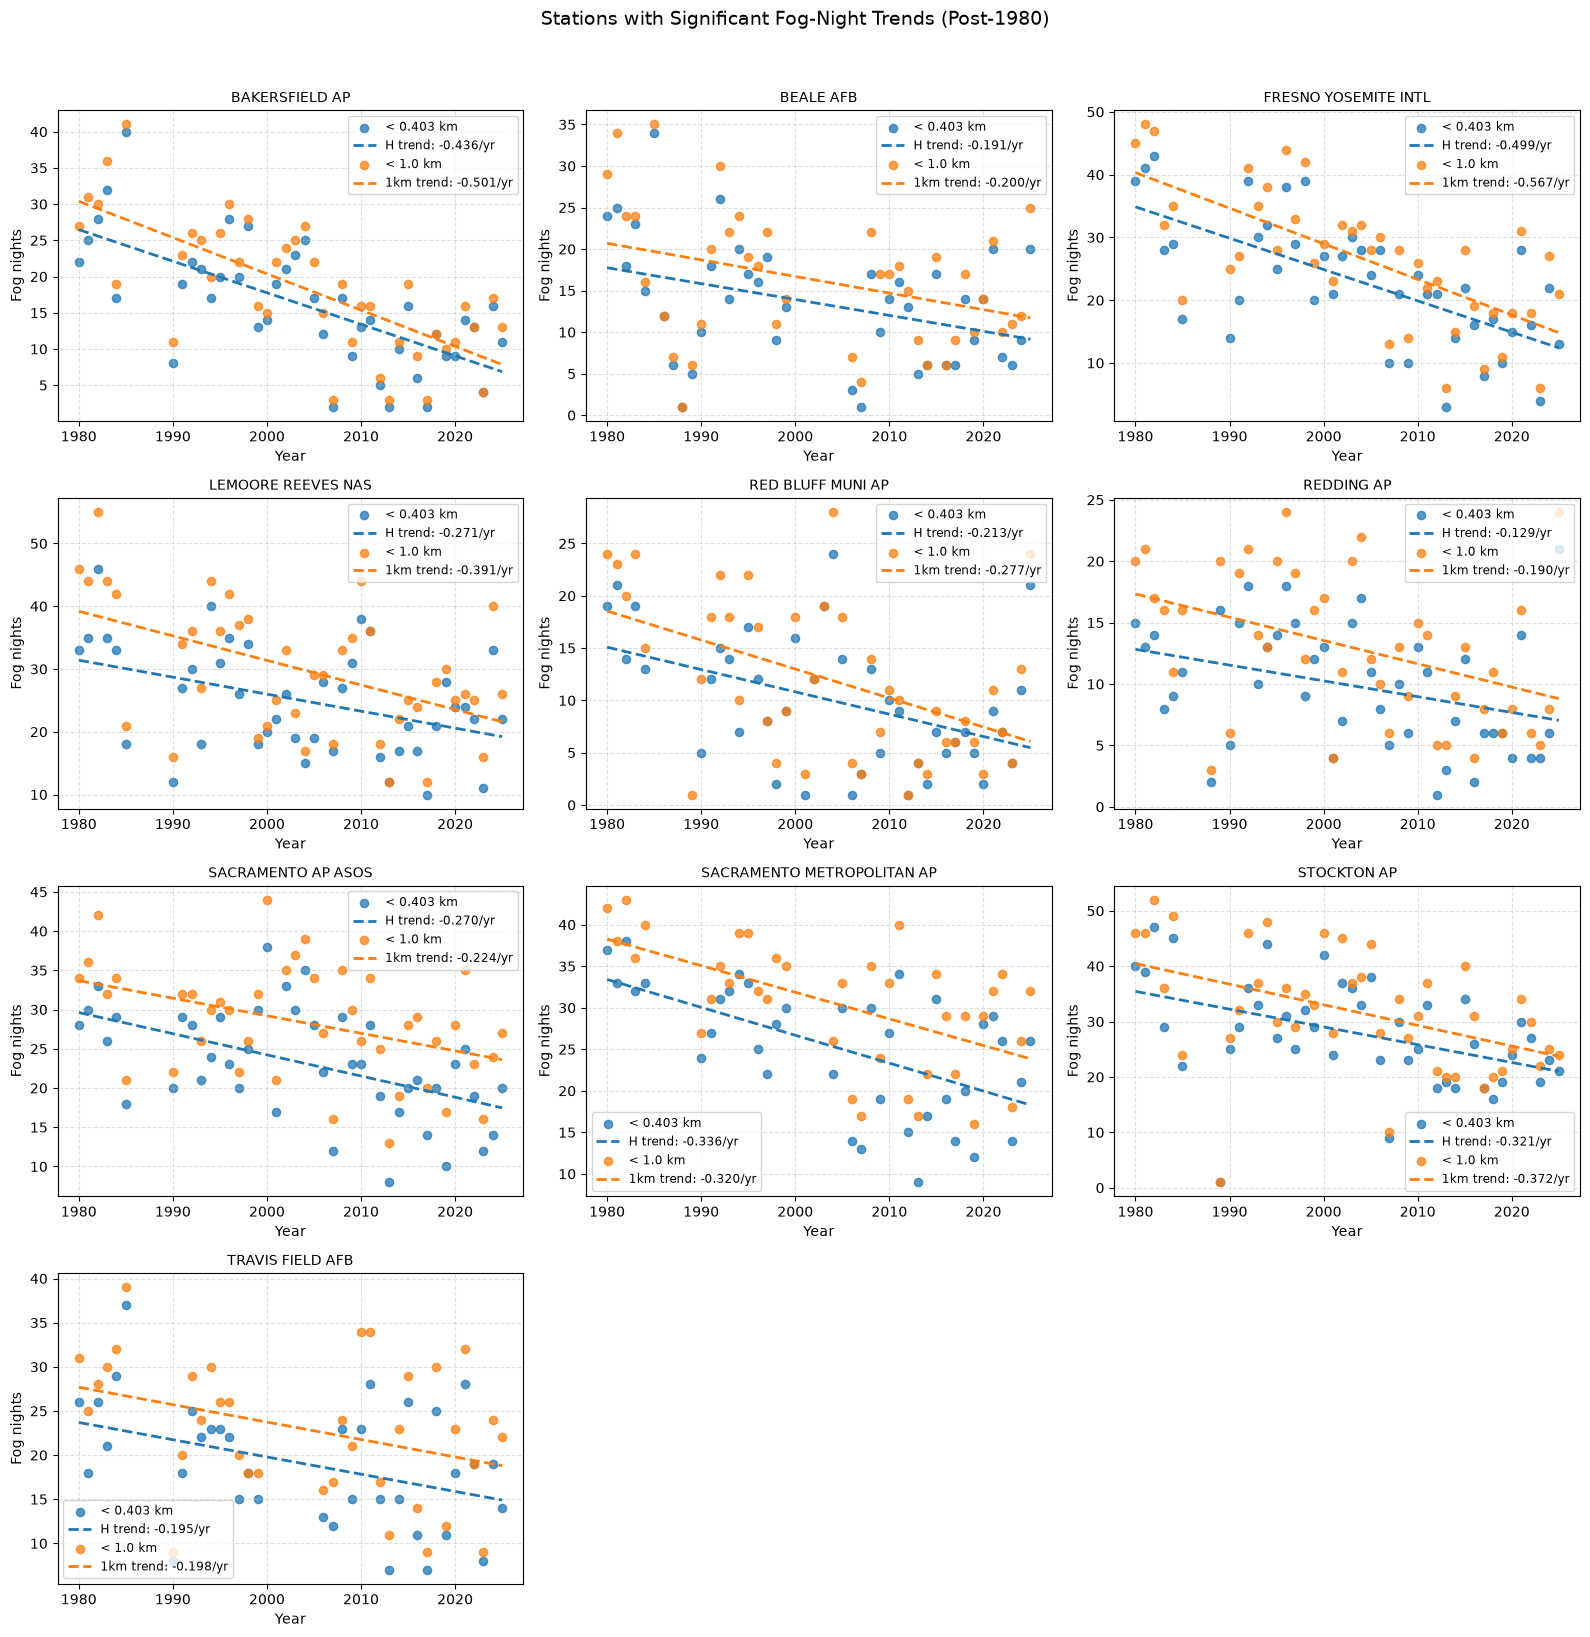

In [46]:

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])
stations_to_plot_nights_post1980 = sorted(stations_h_sig_nights_post1980 | stations_1km_sig_nights_post1980)

if len(stations_to_plot_nights_post1980) == 0:
    print("\nNo significant post-1980 station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights_post1980) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights_post1980):
        ax = axes[idx]

        df_h = post1980_nights_h[post1980_nights_h["STATION"] == station].sort_values("year")
        df_1km = post1980_nights_1km[post1980_nights_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights_post1980 and not df_h.empty:
            model_h_1980 = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h_1980.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h_1980.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights_post1980 and not df_1km.empty:
            model_1km_1980 = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km_1980.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km_1980.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights_post1980):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends (Post-1980)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [47]:
# Compare fog DAYS vs fog NIGHTS (post-1980) and their trend slopes/significance

# --- 1) Average measured fog days/nights per station ---
avg_h_days = post1980_h.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_h"}
)
avg_h_nights = post1980_nights_h.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_h"}
)

avg_1km_days = post1980_1km.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_1km"}
)
avg_1km_nights = post1980_nights_1km.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_1km"}
)

# --- 2) Trend comparison tables (<0.403 km) ---
days_h = trend_stats_low_vis_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_h",
        "p_value": "p_days_h",
        "trend_significant": "sig_days_h",
        "n_obs": "n_days_h",
    }
)

nights_h = trend_stats_nights_h_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_h",
        "p_value": "p_nights_h",
        "trend_significant": "sig_nights_h",
        "n_obs": "n_nights_h",
    }
)

comparison_h = (
    days_h.merge(nights_h, on="STATION", how="outer")
    .merge(avg_h_days, on="STATION", how="left")
    .merge(avg_h_nights, on="STATION", how="left")
)

comparison_h["sig_category_h"] = np.select(
    [
        comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
        comparison_h["sig_days_h"].fillna(False) & ~comparison_h["sig_nights_h"].fillna(False),
        ~comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 3) Trend comparison tables (<1.0 km) ---
days_1km = trend_stats_low_vis_post1980_1km[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_1km",
        "p_value": "p_days_1km",
        "trend_significant": "sig_days_1km",
        "n_obs": "n_days_1km",
    }
)

nights_1km = trend_stats_nights_1km_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_1km",
        "p_value": "p_nights_1km",
        "trend_significant": "sig_nights_1km",
        "n_obs": "n_nights_1km",
    }
)

comparison_1km = (
    days_1km.merge(nights_1km, on="STATION", how="outer")
    .merge(avg_1km_days, on="STATION", how="left")
    .merge(avg_1km_nights, on="STATION", how="left")
)

comparison_1km["sig_category_1km"] = np.select(
    [
        comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
        comparison_1km["sig_days_1km"].fillna(False) & ~comparison_1km["sig_nights_1km"].fillna(False),
        ~comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 4) Print compact outputs ---
print("=== <0.403 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_h.sort_values(["sig_category_h", "STATION"])[
        [
            "STATION",
            "avg_fog_days_h", "avg_fog_nights_h",
            "slope_days_h", "p_days_h", "sig_days_h",
            "slope_nights_h", "p_nights_h", "sig_nights_h",
            "sig_category_h",
        ]
    ]
)

print("\nCounts by significance category (<0.403 km):")
print(comparison_h["sig_category_h"].value_counts())

print("\n=== <1.0 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_1km.sort_values(["sig_category_1km", "STATION"])[
        [
            "STATION",
            "avg_fog_days_1km", "avg_fog_nights_1km",
            "slope_days_1km", "p_days_1km", "sig_days_1km",
            "slope_nights_1km", "p_nights_1km", "sig_nights_1km",
            "sig_category_1km",
        ]
    ]
)

print("\nCounts by significance category (<1.0 km):")
print(comparison_1km["sig_category_1km"].value_counts())

=== <0.403 km: Days vs Nights trend comparison (post-1980) ===
                       STATION  avg_fog_days_h  avg_fog_nights_h  \
0               BAKERSFIELD AP       16.452381         16.047619   
1                    BEALE AFB       14.487179         13.450000   
3         FRESNO YOSEMITE INTL       23.785714         22.928571   
4           LEMOORE REEVES NAS       25.880952         24.928571   
6            RED BLUFF MUNI AP       10.512195          9.878049   
7                   REDDING AP       10.363636          9.840909   
8           SACRAMENTO AP ASOS       23.904762         23.166667   
11  SACRAMENTO METROPOLITAN AP       25.189189         25.108108   
12                 STOCKTON AP       29.380952         27.883721   
13            TRAVIS FIELD AFB       19.305556         18.972222   
2                   CASTLE AFB       29.750000         27.400000   
5       LIVERMORE MUNICIPAL AP       12.307692         12.038462   
9        SACRAMENTO MATHER AFB       19.161290       

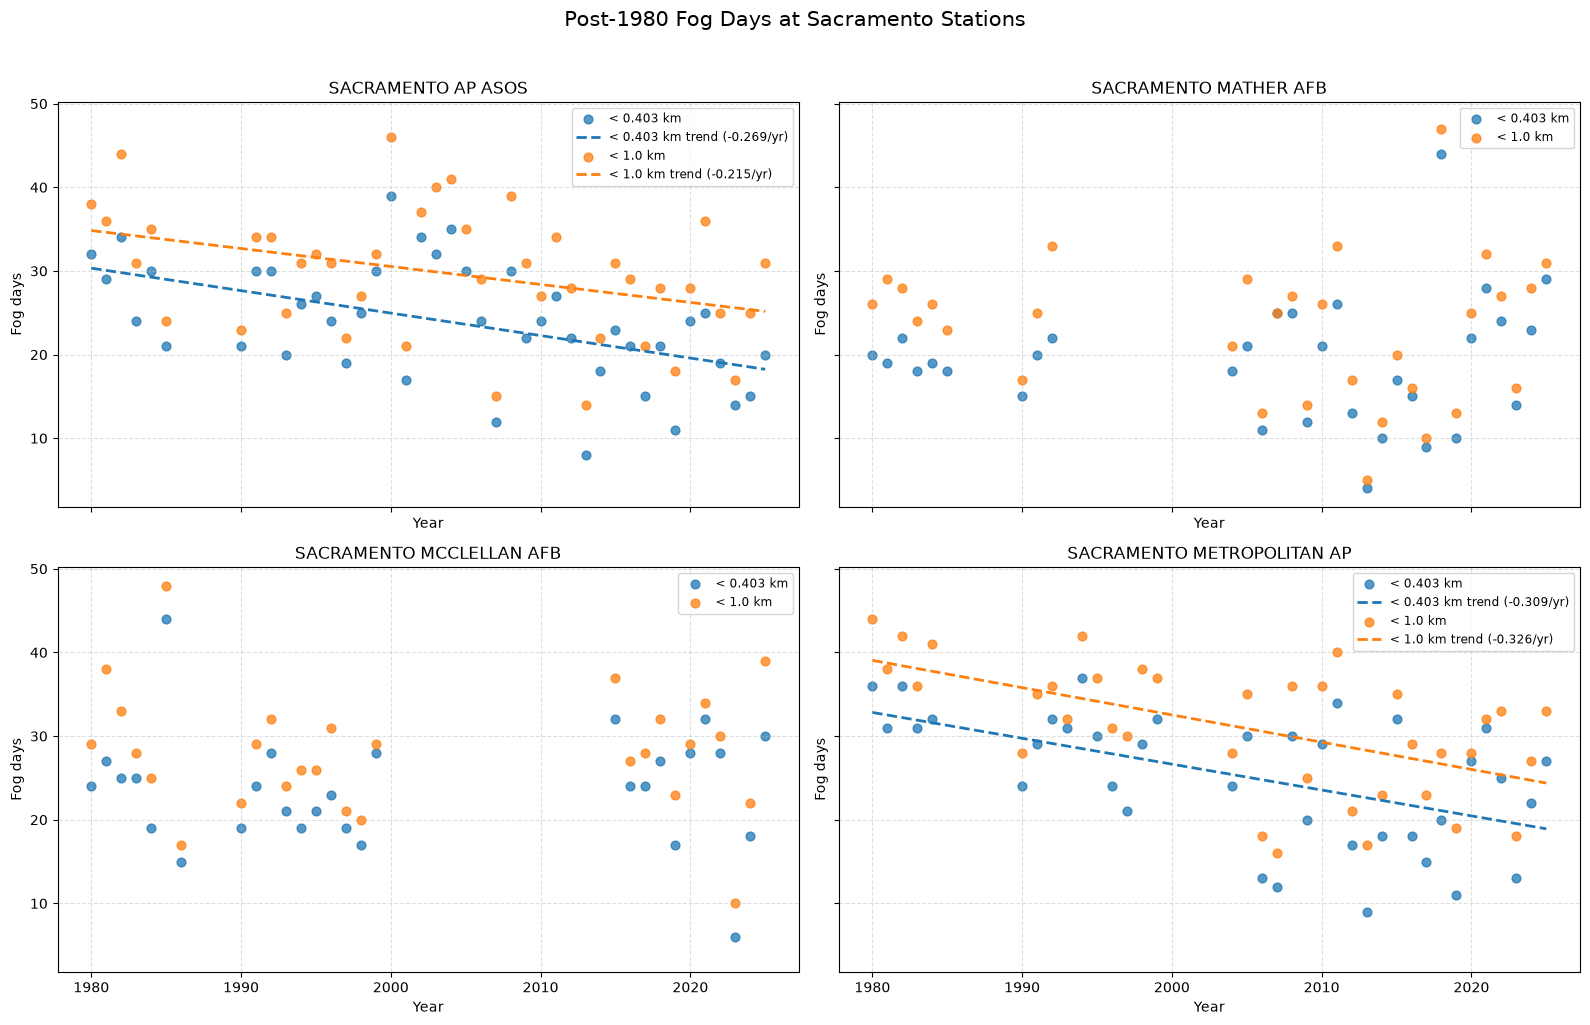

In [48]:
# Scatterplots of post-1980 fog days for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_stations = sorted(
    set(
        post1980_h.loc[
            post1980_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_1km.loc[
            post1980_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

sac_ncols = 2
sac_nrows = int(np.ceil(len(sacramento_stations) / sac_ncols))

fig, axes = plt.subplots(
    sac_nrows,
    sac_ncols,
    figsize=(16, sac_nrows * 5),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, sac_station in enumerate(sacramento_stations):
    ax = axes[idx]

    df_h_sac = post1980_h[
        post1980_h["STATION"] == sac_station
    ].sort_values("year")

    df_1km_sac = post1980_1km[
        post1980_1km["STATION"] == sac_station
    ].sort_values("year")

    if not df_h_sac.empty:
        ax.scatter(
            df_h_sac["year"],
            df_h_sac["fog_days"],
            color="tab:blue",
            alpha=0.75,
            s=40,
            label="< 0.403 km"
        )

        model_h_sac = smf.ols("fog_days ~ year", data=df_h_sac).fit()
        if model_h_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_h_sac["year"],
                model_h_sac.predict(df_h_sac),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"< 0.403 km trend ({model_h_sac.params['year']:.3f}/yr)"
            )

    if not df_1km_sac.empty:
        ax.scatter(
            df_1km_sac["year"],
            df_1km_sac["fog_days"],
            color="tab:orange",
            alpha=0.75,
            s=40,
            label="< 1.0 km"
        )

        model_1km_sac = smf.ols("fog_days ~ year", data=df_1km_sac).fit()
        if model_1km_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_1km_sac["year"],
                model_1km_sac.predict(df_1km_sac),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"< 1.0 km trend ({model_1km_sac.params['year']:.3f}/yr)"
            )

    ax.set_title(sac_station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog days")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Days at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

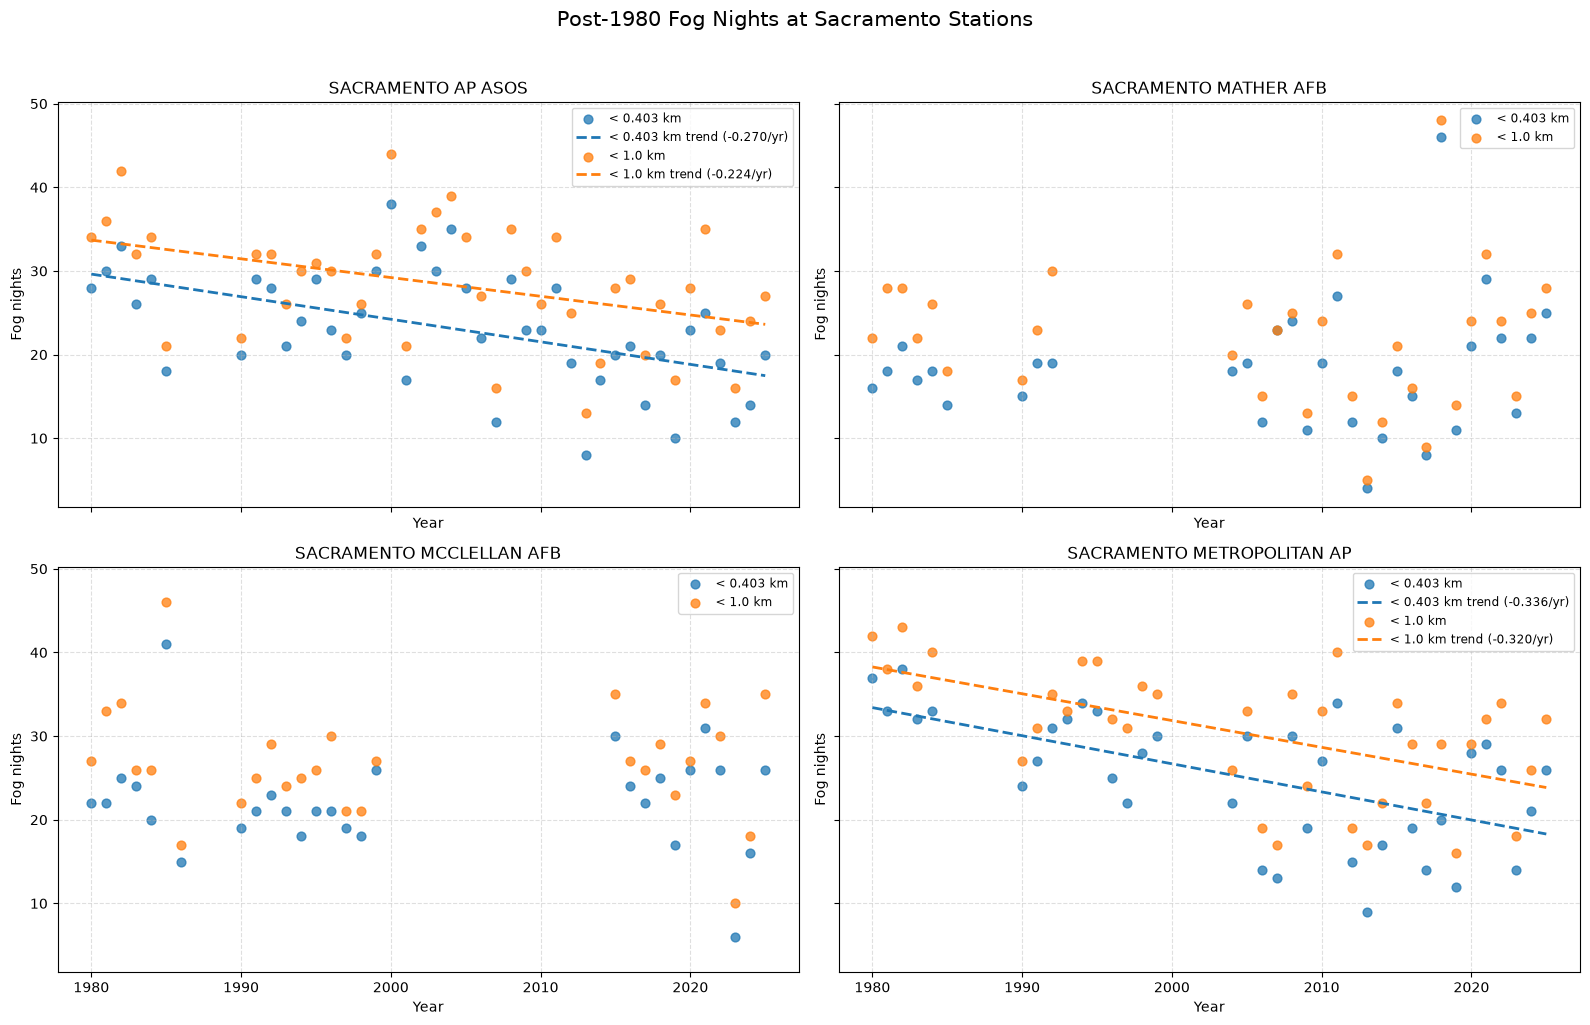

In [49]:
# Scatterplots of post-1980 fog nights for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_night_stations = sorted(
    set(
        post1980_nights_h.loc[
            post1980_nights_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_nights_1km.loc[
            post1980_nights_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])

ncols = 2
nrows = int(np.ceil(len(sacramento_night_stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(16, nrows * 5), sharex=True, sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, station in enumerate(sacramento_night_stations):
    ax = axes[idx]

    df_h = post1980_nights_h[
        post1980_nights_h["STATION"] == station
    ].sort_values("year")

    df_1km = post1980_nights_1km[
        post1980_nights_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"], df_h["fog_nights"],
            color="tab:blue", alpha=0.75, s=40,
            label="< 0.403 km"
        )

        if station in stations_h_sig_nights_post1980:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.plot(
                df_h["year"], model_h.predict(df_h),
                color="tab:blue", linestyle="--", linewidth=2,
                label=f"< 0.403 km trend ({model_h.params['year']:.3f}/yr)"
            )

    if not df_1km.empty:
        ax.scatter(
            df_1km["year"], df_1km["fog_nights"],
            color="tab:orange", alpha=0.75, s=40,
            label="< 1.0 km"
        )

        if station in stations_1km_sig_nights_post1980:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.plot(
                df_1km["year"], model_1km.predict(df_1km),
                color="tab:orange", linestyle="--", linewidth=2,
                label=f"< 1.0 km trend ({model_1km.params['year']:.3f}/yr)"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog nights")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_night_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Nights at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

Break - reworking things to fog season

In [50]:
# Count fog-season days from November through March.
# Each season is labeled by the year in which November occurs:
# November 1980 through March 1981 -> fog season 1980–81.

season_rows = CV_filtered_rows.copy()
season_rows["DATE"] = pd.to_datetime(season_rows["DATE"])

# Retain only November through March
season_rows = season_rows[season_rows["month"].isin([11, 12, 1, 2, 3])].copy()

# Assign November–December to the current year and January–March to the previous year
season_rows["fog_season"] = np.where(
    season_rows["month"].isin([11, 12]),
    season_rows["year"],
    season_rows["year"] - 1
)

# Apply the two visibility thresholds
season_rows_h = season_rows[
    (season_rows["HourlyVisibility"] < 0.403)
    & (season_rows["HourlyPrecipitation"] < 0.03)
].copy()

season_rows_1km = season_rows[
    (season_rows["HourlyVisibility"] < 1.000)
    & (season_rows["HourlyPrecipitation"] < 0.03)
].copy()

# Count unique station-days within each fog season
fog_season_days_h = (
    season_rows_h
    .drop_duplicates(["STATION", "fog_season", "year", "month", "day"])
    .groupby(["STATION", "fog_season"], as_index=False)
    .size()
    .rename(columns={"size": "fog_season_days_h"})
    .sort_values(["STATION", "fog_season"])
)

fog_season_days_1km = (
    season_rows_1km
    .drop_duplicates(["STATION", "fog_season", "year", "month", "day"])
    .groupby(["STATION", "fog_season"], as_index=False)
    .size()
    .rename(columns={"size": "fog_season_days_1km"})
    .sort_values(["STATION", "fog_season"])
)

print("Fog-season days (<0.403 km):")
print(fog_season_days_h.head())

print("\nFog-season days (<1.0 km):")
print(fog_season_days_1km.head())

Fog-season days (<0.403 km):
          STATION  fog_season  fog_season_days_h
0  BAKERSFIELD AP        1928                 10
1  BAKERSFIELD AP        1929                 17
2  BAKERSFIELD AP        1930                 23
3  BAKERSFIELD AP        1931                 15
4  BAKERSFIELD AP        1932                 13

Fog-season days (<1.0 km):
          STATION  fog_season  fog_season_days_1km
0  BAKERSFIELD AP        1927                    1
1  BAKERSFIELD AP        1928                   21
2  BAKERSFIELD AP        1929                   19
3  BAKERSFIELD AP        1930                   25
4  BAKERSFIELD AP        1931                   16


In [51]:
# Determine hourly coverage for each station and November–March fog season.
# Multiple observations within the same clock hour count as one observed hour.

hourly_coverage = season_rows.copy()
hourly_coverage["DATE"] = pd.to_datetime(hourly_coverage["DATE"])
hourly_coverage["observation_hour"] = hourly_coverage["DATE"].dt.floor("h")

hourly_coverage = (
    hourly_coverage
    .groupby(["STATION", "fog_season"], as_index=False)
    .agg(
        observed_records=("DATE", "size"),
        observed_hours=("observation_hour", "nunique"),
        first_observation=("observation_hour", "min"),
        last_observation=("observation_hour", "max")
    )
)

# Calculate the expected number of hours in each November–March season.
hourly_coverage["season_start"] = pd.to_datetime(
    hourly_coverage["fog_season"].astype(str) + "-11-01"
)
hourly_coverage["season_end"] = pd.to_datetime(
    (hourly_coverage["fog_season"] + 1).astype(str) + "-03-31"
) + pd.Timedelta(hours=23)

hourly_coverage["expected_hours"] = (
    (hourly_coverage["season_end"] - hourly_coverage["season_start"])
    .dt.total_seconds()
    .div(3600)
    .add(1)
    .astype(int)
)

hourly_coverage["coverage_percent"] = (
    100
    * hourly_coverage["observed_hours"]
    / hourly_coverage["expected_hours"]
)

hourly_coverage = hourly_coverage.sort_values(["STATION", "fog_season"])

print("Hourly station-season coverage:")
print(hourly_coverage.head())

print("\nHourly coverage summary:")
print(
    hourly_coverage[
        ["observed_hours", "expected_hours", "coverage_percent"]
    ].describe()
)

Hourly station-season coverage:
          STATION  fog_season  observed_records  observed_hours  \
0  BAKERSFIELD AP        1927                25              25   
1  BAKERSFIELD AP        1928               524             524   
2  BAKERSFIELD AP        1929               952             952   
3  BAKERSFIELD AP        1930               947             947   
4  BAKERSFIELD AP        1931              3630            3630   

    first_observation    last_observation season_start          season_end  \
0 1928-01-01 01:00:00 1928-01-15 11:00:00   1927-11-01 1928-03-31 23:00:00   
1 1928-11-01 01:00:00 1929-03-30 04:00:00   1928-11-01 1929-03-31 23:00:00   
2 1929-11-01 07:00:00 1930-03-31 10:00:00   1929-11-01 1930-03-31 23:00:00   
3 1930-11-04 21:00:00 1931-03-24 18:00:00   1930-11-01 1931-03-31 23:00:00   
4 1931-11-01 00:00:00 1932-03-31 23:00:00   1931-11-01 1932-03-31 23:00:00   

   expected_hours  coverage_percent  
0            3648          0.685307  
1            3624   

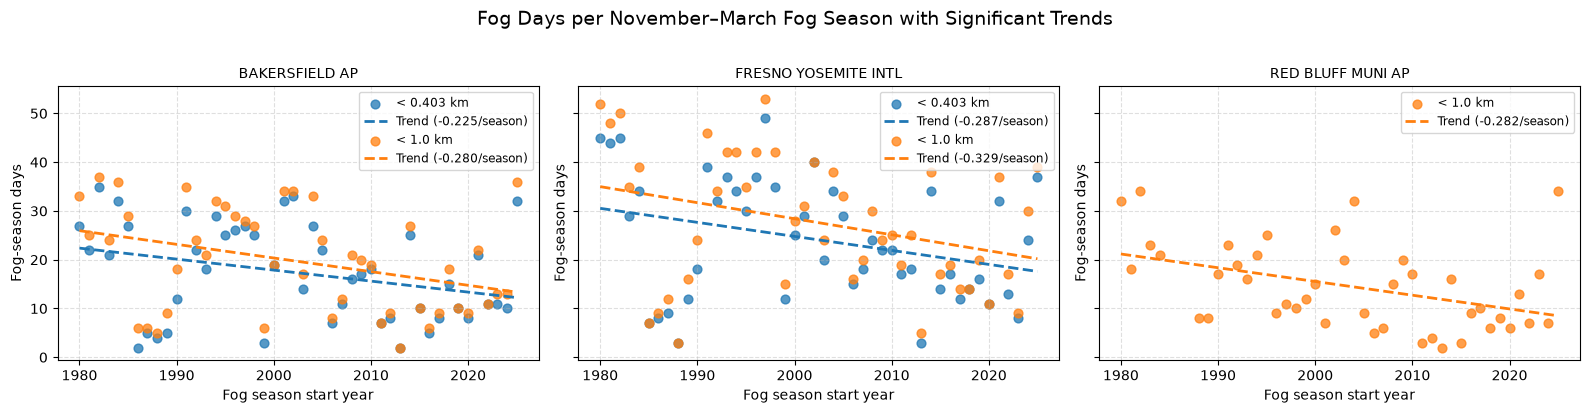

Stations plotted: ['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'RED BLUFF MUNI AP']


In [52]:
# Plot fog-season days for stations with significant post-1980 trends.
# Trend lines are fitted separately for <0.403 km and <1.0 km visibility.

days_h_post1980 = fog_season_days_h[
    fog_season_days_h["fog_season"] >= 1980
].copy()

days_1km_post1980 = fog_season_days_1km[
    fog_season_days_1km["fog_season"] >= 1980
].copy()

trend_h = {}
for station, station_df in days_h_post1980.groupby("STATION"):
    if len(station_df) >= 3:
        model = smf.ols(
            "fog_season_days_h ~ fog_season",
            data=station_df
        ).fit()
        if model.pvalues["fog_season"] < 0.05:
            trend_h[station] = model

trend_1km = {}
for station, station_df in days_1km_post1980.groupby("STATION"):
    if len(station_df) >= 3:
        model = smf.ols(
            "fog_season_days_1km ~ fog_season",
            data=station_df
        ).fit()
        if model.pvalues["fog_season"] < 0.05:
            trend_1km[station] = model

stations_to_plot_season = sorted(set(trend_h) | set(trend_1km))

if not stations_to_plot_season:
    print("No significant post-1980 fog-season trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_season) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, nrows * 4),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_season):
        ax = axes[idx]

        df_h = days_h_post1980[
            days_h_post1980["STATION"] == station
        ].sort_values("fog_season")

        df_1km = days_1km_post1980[
            days_1km_post1980["STATION"] == station
        ].sort_values("fog_season")

        if station in trend_h and not df_h.empty:
            model_h = trend_h[station]
            ax.scatter(
                df_h["fog_season"],
                df_h["fog_season_days_h"],
                color="tab:blue",
                alpha=0.75,
                s=40,
                label="< 0.403 km"
            )
            ax.plot(
                df_h["fog_season"],
                model_h.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"Trend ({model_h.params['fog_season']:.3f}/season)"
            )

        if station in trend_1km and not df_1km.empty:
            model_1km = trend_1km[station]
            ax.scatter(
                df_1km["fog_season"],
                df_1km["fog_season_days_1km"],
                color="tab:orange",
                alpha=0.75,
                s=40,
                label="< 1.0 km"
            )
            ax.plot(
                df_1km["fog_season"],
                model_1km.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"Trend ({model_1km.params['fog_season']:.3f}/season)"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Fog season start year")
        ax.set_ylabel("Fog-season days")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small")

    for ax in axes[len(stations_to_plot_season):]:
        fig.delaxes(ax)

    fig.suptitle(
        "Fog Days per November–March Fog Season with Significant Trends",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

    print("Stations plotted:", stations_to_plot_season)

In [53]:
# Determine station coverage for each November–March fog season.
# Coverage is based on unique station-days with at least one observation.

season_coverage = (
    season_rows.assign(
        DATE=pd.to_datetime(season_rows["DATE"]),
        date_only=pd.to_datetime(season_rows["DATE"]).dt.normalize()
    )
    .groupby(["STATION", "fog_season"], as_index=False)
    .agg(
        observed_records=("DATE", "size"),
        observed_days=("date_only", "nunique"),
        first_observation=("date_only", "min"),
        last_observation=("date_only", "max")
    )
)

# Calculate the expected number of calendar days in each complete fog season.
season_coverage["season_start"] = pd.to_datetime(
    season_coverage["fog_season"].astype(str) + "-11-01"
)
season_coverage["season_end"] = pd.to_datetime(
    (season_coverage["fog_season"] + 1).astype(str) + "-03-31"
)

season_coverage["expected_days"] = (
    season_coverage["season_end"] - season_coverage["season_start"]
).dt.days + 1

season_coverage["coverage_percent"] = (
    100 * season_coverage["observed_days"]
    / season_coverage["expected_days"]
)

season_coverage = season_coverage.sort_values(["STATION", "fog_season"])

print("Station-season coverage:")
print(season_coverage.head())

print("\nCoverage summary:")
print(
    season_coverage[
        ["observed_days", "expected_days", "coverage_percent"]
    ].describe()
)

Station-season coverage:
          STATION  fog_season  observed_records  observed_days  \
0  BAKERSFIELD AP        1927                25              9   
1  BAKERSFIELD AP        1928               524            116   
2  BAKERSFIELD AP        1929               952             94   
3  BAKERSFIELD AP        1930               947             94   
4  BAKERSFIELD AP        1931              3630            152   

  first_observation last_observation season_start season_end  expected_days  \
0        1928-01-01       1928-01-15   1927-11-01 1928-03-31            152   
1        1928-11-01       1929-03-30   1928-11-01 1929-03-31            151   
2        1929-11-01       1930-03-31   1929-11-01 1930-03-31            151   
3        1930-11-04       1931-03-24   1930-11-01 1931-03-31            151   
4        1931-11-01       1932-03-31   1931-11-01 1932-03-31            152   

   coverage_percent  
0          5.921053  
1         76.821192  
2         62.251656  
3         62.25

Fresno stations found: ['FRESNO YOSEMITE INTL']

Fog-season days (<0.403 km) for Fresno stations:
                  STATION  fog_season  fog_season_days_h
220  FRESNO YOSEMITE INTL        1941                 26
221  FRESNO YOSEMITE INTL        1942                 43
222  FRESNO YOSEMITE INTL        1943                 24
223  FRESNO YOSEMITE INTL        1944                 36
224  FRESNO YOSEMITE INTL        1945                 19
..                    ...         ...                ...
297  FRESNO YOSEMITE INTL        2021                 32
298  FRESNO YOSEMITE INTL        2022                 13
299  FRESNO YOSEMITE INTL        2023                  8
300  FRESNO YOSEMITE INTL        2024                 24
301  FRESNO YOSEMITE INTL        2025                 37

[82 rows x 3 columns]

Fog-season days (<1.0 km) for Fresno stations:
                  STATION  fog_season  fog_season_days_1km
221  FRESNO YOSEMITE INTL        1941                   27
222  FRESNO YOSEMITE INTL    

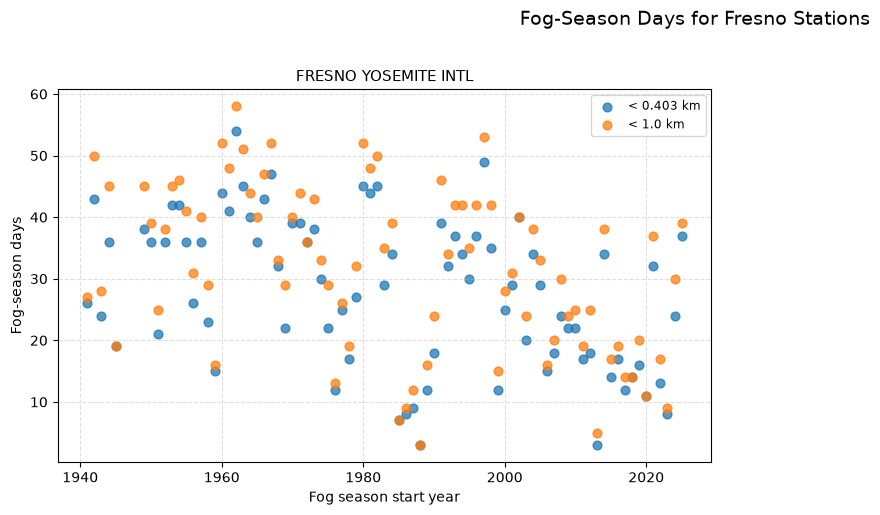

In [54]:
# Total fog days per fog season for FRESNO stations, with plots for each station

fresno_season_days_h = fog_season_days_h[
    fog_season_days_h["STATION"].str.contains("FRESNO", case=False, na=False)
]
fresno_season_days_1km = fog_season_days_1km[
    fog_season_days_1km["STATION"].str.contains("FRESNO", case=False, na=False)
]

fresno_stations = sorted(
    set(fresno_season_days_h["STATION"]) | set(fresno_season_days_1km["STATION"])
)

print("Fresno stations found:", fresno_stations)
print("\nFog-season days (<0.403 km) for Fresno stations:")
print(fresno_season_days_h)
print("\nFog-season days (<1.0 km) for Fresno stations:")
print(fresno_season_days_1km)

ncols = 2
nrows = int(np.ceil(len(fresno_stations) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

for idx, station in enumerate(fresno_stations):
    ax = axes[idx]

    df_h = fresno_season_days_h[
        fresno_season_days_h["STATION"] == station
    ].sort_values("fog_season")

    df_1km = fresno_season_days_1km[
        fresno_season_days_1km["STATION"] == station
    ].sort_values("fog_season")

    if not df_h.empty:
        ax.scatter(
            df_h["fog_season"], df_h["fog_season_days_h"],
            color="tab:blue", alpha=0.75, s=40, label="< 0.403 km"
        )

    if not df_1km.empty:
        ax.scatter(
            df_1km["fog_season"], df_1km["fog_season_days_1km"],
            color="tab:orange", alpha=0.75, s=40, label="< 1.0 km"
        )

    ax.set_title(station, fontsize=11)
    ax.set_xlabel("Fog season start year")
    ax.set_ylabel("Fog-season days")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(fresno_stations):]:
    fig.delaxes(ax)

fig.suptitle("Fog-Season Days for Fresno Stations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# Average fog-season days for each Fresno station
fresno_avg_h = (
    fog_season_days_h[
        fog_season_days_h["STATION"].str.contains("FRESNO", case=False, na=False)
    ]
    .groupby("STATION", as_index=False)["fog_season_days_h"]
    .mean()
    .rename(columns={"fog_season_days_h": "avg_fog_season_days_h"})
    .sort_values("avg_fog_season_days_h", ascending=False)
)

fresno_avg_1km = (
    fog_season_days_1km[
        fog_season_days_1km["STATION"].str.contains("FRESNO", case=False, na=False)
    ]
    .groupby("STATION", as_index=False)["fog_season_days_1km"]
    .mean()
    .rename(columns={"fog_season_days_1km": "avg_fog_season_days_1km"})
    .sort_values("avg_fog_season_days_1km", ascending=False)
)

fresno_avg_by_station = fresno_avg_h.merge(fresno_avg_1km, on="STATION", how="outer")

print("Average fog days per fog season for Fresno stations:")
print(fresno_avg_by_station)

Average fog days per fog season for Fresno stations:
                STATION  avg_fog_season_days_h  avg_fog_season_days_1km
0  FRESNO YOSEMITE INTL              27.987805                31.731707
